# Adult Census Income Notebook

## The first part of this notebook is adapted from the original author's work.

## The second part presents our responsible data science evaluation of the original author's analysis of the Adult Census Income dataset.

# Part I: Original author's work

### Data Set Information:
##### Extraction was done by Barry Becker from the 1994 Census database.

##### Prediction task is to determine whether a person makes more 50K a year or less than that.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing Libraries and Dataset

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


<Axes: >

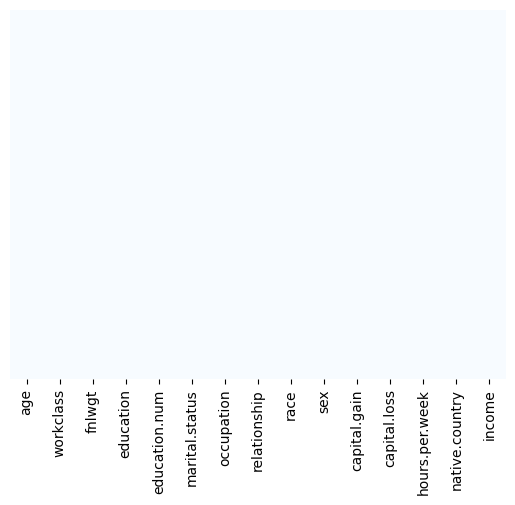

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Blues')

#### So, There are no null values in the dataset

In [ ]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

### Count plot on Income

<Axes: xlabel='income', ylabel='count'>

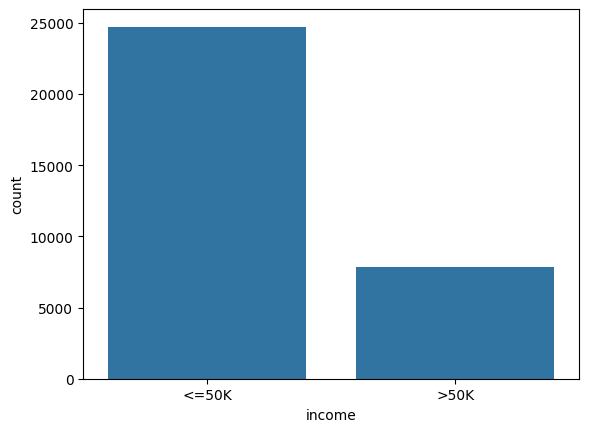

In [ ]:
sns.countplot(x='income', data=df)

### Income Based on Marital Status

<Axes: xlabel='income', ylabel='count'>

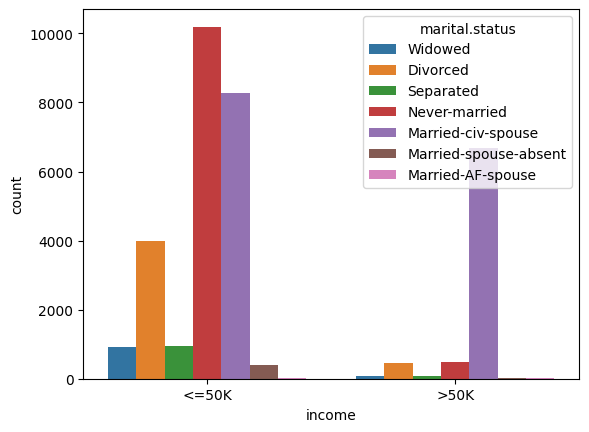

In [ ]:
sns.countplot(x='income', hue='marital.status', data=df)

### Income Based on WorkClass

In [ ]:
df['workclass'].unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

<Axes: xlabel='income', ylabel='count'>

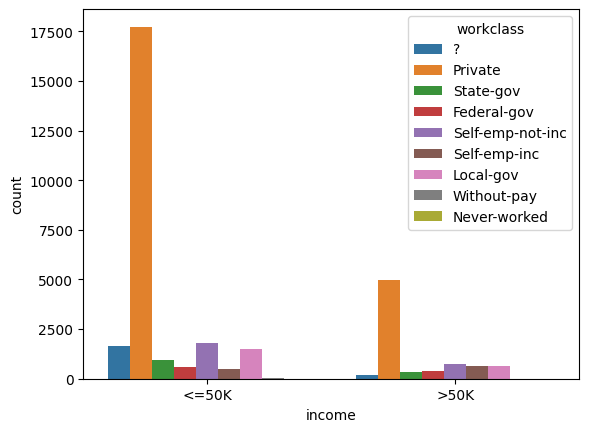

In [ ]:
sns.countplot(x='income', hue='workclass', data=df)

### Income Based on Sex

<Axes: xlabel='income', ylabel='count'>

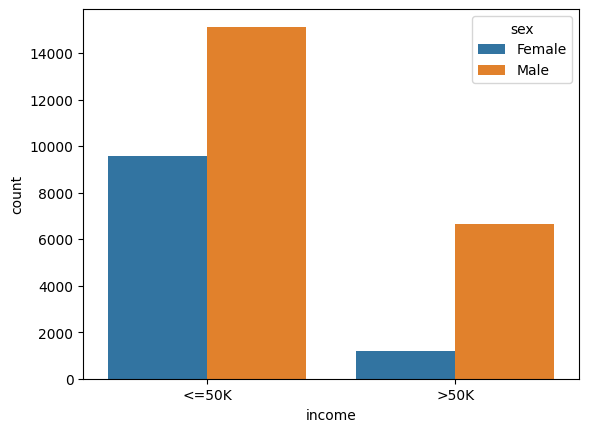

In [ ]:
sns.countplot(x='income', hue='sex', data=df)

### Number of people in each age category

/tmp/ipykernel_20234/2526890032.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'].dropna(), kde=False, color='red', bins=40)


<Axes: xlabel='age'>

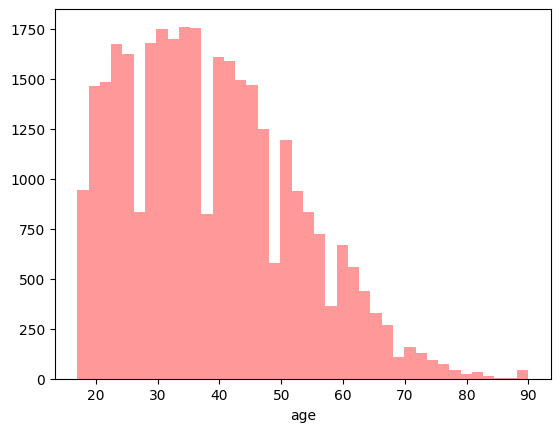

In [ ]:
sns.distplot(df['age'].dropna(), kde=False, color='red', bins=40)

### Income Based on Number of hours a person of certain age is working

<Axes: xlabel='hours.per.week', ylabel='age'>

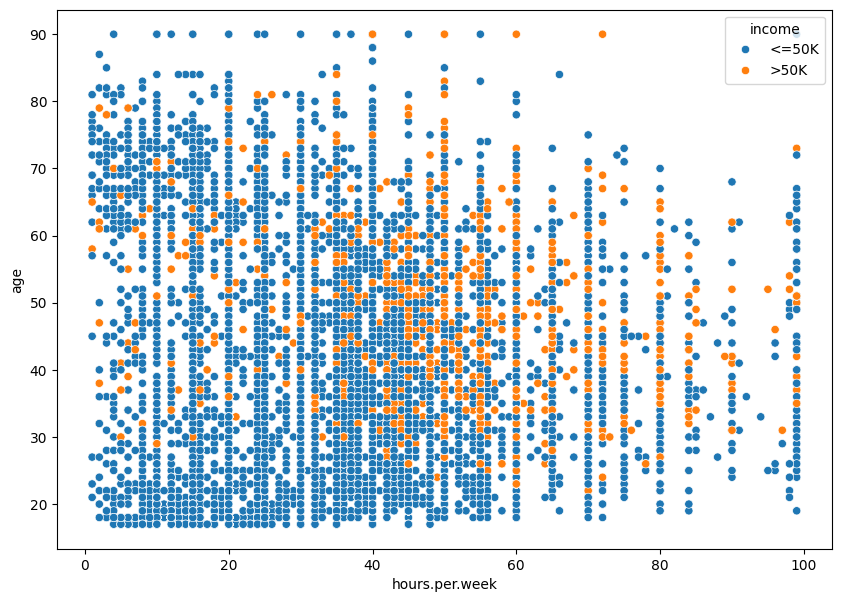

In [ ]:
plt.figure(figsize = (10,7))
sns.scatterplot(x=df['hours.per.week'], y=df['age'], hue=df['income'])

### Income Based on Occupation

/tmp/ipykernel_20234/101827241.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.countplot(x='income', hue='occupation', data=df, color='red')


<Axes: xlabel='income', ylabel='count'>

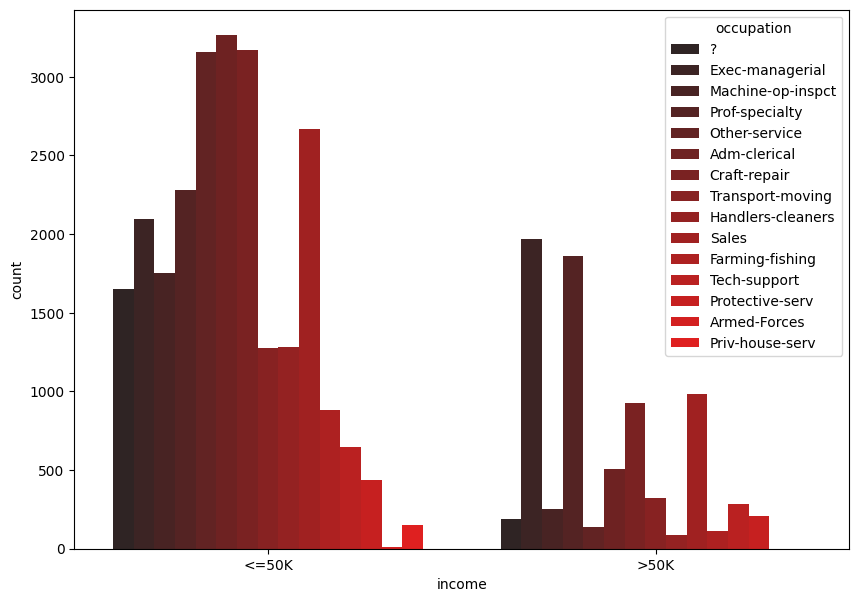

In [ ]:
plt.figure(figsize=(10,7))
sns.countplot(x='income', hue='occupation', data=df, color='red')

### Correlation between variables

<Axes: >

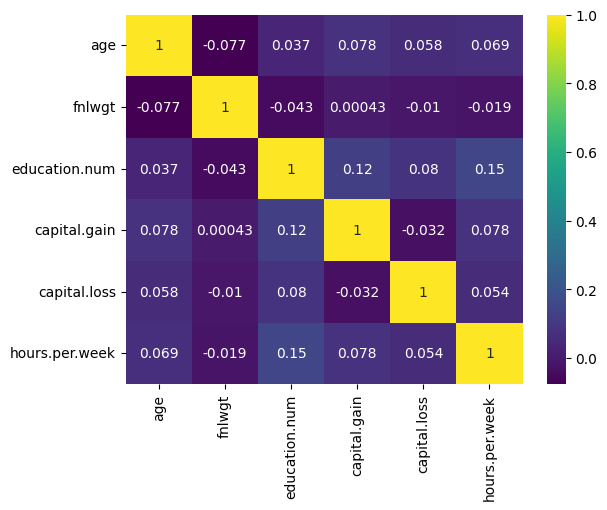

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis')

# Feature Engineering

In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


<Axes: xlabel='age'>

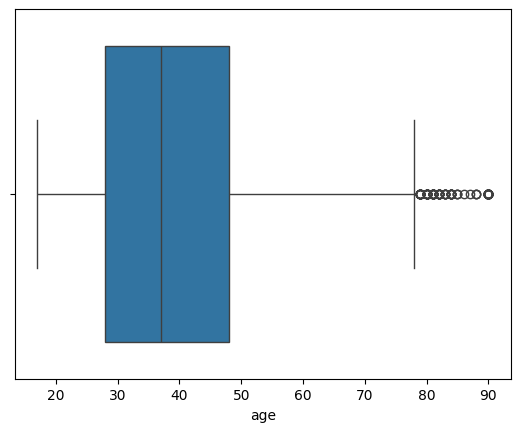

In [ ]:
sns.boxplot(x = df['age'])

#### As you can see in the above boxplot, there are some outliers in age variable

### Outlier Removal in age Column

In [ ]:
Q1 = df.age.quantile(0.25)
Q3 = df.age.quantile(0.75)
Q1, Q3

(np.float64(28.0), np.float64(48.0))

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(20.0)

In [ ]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(-2.0), np.float64(78.0))

#### Outlier records

In [ ]:
df[(df.age<lower_limit)|(df.age> upper_limit)]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
118,83,Self-emp-inc,153183,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2392,55,United-States,>50K
128,81,Private,177408,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2377,26,United-States,>50K
199,90,Private,51744,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,2206,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31939,82,Self-emp-not-inc,71438,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,20,United-States,<=50K
32305,90,Private,313749,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,25,United-States,<=50K
32468,85,Private,98611,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,3,Poland,<=50K
32500,82,?,403910,HS-grad,9,Never-married,?,Not-in-family,White,Male,0,0,3,United-States,<=50K


#### Removing the outlier

In [ ]:
df = df[(df.age>lower_limit)&(df.age<upper_limit)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32395 entries, 2 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32395 non-null  int64 
 1   workclass       32395 non-null  object
 2   fnlwgt          32395 non-null  int64 
 3   education       32395 non-null  object
 4   education.num   32395 non-null  int64 
 5   marital.status  32395 non-null  object
 6   occupation      32395 non-null  object
 7   relationship    32395 non-null  object
 8   race            32395 non-null  object
 9   sex             32395 non-null  object
 10  capital.gain    32395 non-null  int64 
 11  capital.loss    32395 non-null  int64 
 12  hours.per.week  32395 non-null  int64 
 13  native.country  32395 non-null  object
 14  income          32395 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


#### Handling workclass column

In [ ]:
df.workclass.unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

In [ ]:
df['workclass'].mode()

,workclass
0,Private


In [ ]:
def replace(col):
    if col == '?':
        return 'Private'
    else:
        return col

df['workclass'] = df['workclass'].apply(replace)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
2,66,Private,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [ ]:
df = pd.get_dummies(df, columns=['workclass'], drop_first = True)
df.head()

,age,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,...,hours.per.week,native.country,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
2,66,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,...,40,United-States,<=50K,False,False,True,False,False,False,False
3,54,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,...,40,United-States,<=50K,False,False,True,False,False,False,False
4,41,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,...,40,United-States,<=50K,False,False,True,False,False,False,False
5,34,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,...,45,United-States,<=50K,False,False,True,False,False,False,False
6,38,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,...,40,United-States,<=50K,False,False,True,False,False,False,False


#### Handling education column

In [ ]:
df.education.unique()

array(['Some-college', '7th-8th', 'HS-grad', '10th', 'Doctorate',
       'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-acdm',
       'Assoc-voc', '1st-4th', '5th-6th', '12th', '9th', 'Preschool'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['education'], drop_first = True)
df.head()

,age,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,...,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college
2,66,186061,10,Widowed,?,Unmarried,Black,Female,0,4356,...,False,False,False,False,False,False,False,False,False,True
3,54,140359,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,...,False,False,False,False,False,False,False,False,False,False
4,41,264663,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,...,False,False,False,False,False,False,False,False,False,True
5,34,216864,9,Divorced,Other-service,Unmarried,White,Female,0,3770,...,False,False,False,False,False,True,False,False,False,False
6,38,150601,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,...,False,False,False,False,False,False,False,False,False,False


#### Handling marital status column

In [ ]:
df['marital.status'].unique()

array(['Widowed', 'Divorced', 'Separated', 'Never-married',
       'Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['marital.status'], drop_first = True)
df.head()

,age,fnlwgt,education.num,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,...,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
2,66,186061,10,?,Unmarried,Black,Female,0,4356,40,...,False,False,False,True,False,False,False,False,False,True
3,54,140359,4,Machine-op-inspct,Unmarried,White,Female,0,3900,40,...,False,False,False,False,False,False,False,False,False,False
4,41,264663,10,Prof-specialty,Own-child,White,Female,0,3900,40,...,False,False,False,True,False,False,False,False,True,False
5,34,216864,9,Other-service,Unmarried,White,Female,0,3770,45,...,False,False,False,False,False,False,False,False,False,False
6,38,150601,6,Adm-clerical,Unmarried,White,Male,0,3770,40,...,False,False,False,False,False,False,False,False,True,False


#### Handling Occupation column

In [ ]:
df['occupation'].unique()

array(['?', 'Machine-op-inspct', 'Prof-specialty', 'Other-service',
       'Adm-clerical', 'Craft-repair', 'Exec-managerial',
       'Transport-moving', 'Handlers-cleaners', 'Sales',
       'Farming-fishing', 'Tech-support', 'Protective-serv',
       'Armed-Forces', 'Priv-house-serv'], dtype=object)

In [ ]:
df['occupation'].mode()

,occupation
0,Prof-specialty


In [ ]:
def change(col):
    if col == '?':
        return 'Prof-specialty'
    else:
        return col

df['occupation'] = df['occupation'].apply(change)
df.head()

,age,fnlwgt,education.num,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,...,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
2,66,186061,10,Prof-specialty,Unmarried,Black,Female,0,4356,40,...,False,False,False,True,False,False,False,False,False,True
3,54,140359,4,Machine-op-inspct,Unmarried,White,Female,0,3900,40,...,False,False,False,False,False,False,False,False,False,False
4,41,264663,10,Prof-specialty,Own-child,White,Female,0,3900,40,...,False,False,False,True,False,False,False,False,True,False
5,34,216864,9,Other-service,Unmarried,White,Female,0,3770,45,...,False,False,False,False,False,False,False,False,False,False
6,38,150601,6,Adm-clerical,Unmarried,White,Male,0,3770,40,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
df = pd.get_dummies(df, columns=['occupation'], drop_first = True)
df.head()

,age,fnlwgt,education.num,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
2,66,186061,10,Unmarried,Black,Female,0,4356,40,United-States,...,False,False,False,False,False,True,False,False,False,False
3,54,140359,4,Unmarried,White,Female,0,3900,40,United-States,...,False,False,True,False,False,False,False,False,False,False
4,41,264663,10,Own-child,White,Female,0,3900,40,United-States,...,False,False,False,False,False,True,False,False,False,False
5,34,216864,9,Unmarried,White,Female,0,3770,45,United-States,...,False,False,False,True,False,False,False,False,False,False
6,38,150601,6,Unmarried,White,Male,0,3770,40,United-States,...,False,False,False,False,False,False,False,False,False,False


#### Handling relationship column

In [ ]:
df['relationship'].unique()

array(['Unmarried', 'Own-child', 'Other-relative', 'Not-in-family',
       'Husband', 'Wife'], dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['relationship'], drop_first = True)
df.head()

,age,fnlwgt,education.num,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
2,66,186061,10,Black,Female,0,4356,40,United-States,<=50K,...,True,False,False,False,False,False,False,False,True,False
3,54,140359,4,White,Female,0,3900,40,United-States,<=50K,...,False,False,False,False,False,False,False,False,True,False
4,41,264663,10,White,Female,0,3900,40,United-States,<=50K,...,True,False,False,False,False,False,False,True,False,False
5,34,216864,9,White,Female,0,3770,45,United-States,<=50K,...,False,False,False,False,False,False,False,False,True,False
6,38,150601,6,White,Male,0,3770,40,United-States,<=50K,...,False,False,False,False,False,False,False,False,True,False


#### Handling Race column

##### Race Won't be a deciding factor for income. So, I am going to Drop that column

In [ ]:
df.drop('race', axis = 1, inplace = True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Local-gov,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
2,66,186061,10,Female,0,4356,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,False,True,False
3,54,140359,4,Female,0,3900,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
4,41,264663,10,Female,0,3900,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,True,False,False
5,34,216864,9,Female,0,3770,45,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
6,38,150601,6,Male,0,3770,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False


#### Handling Sex Column

In [ ]:
df['sex'] = pd.get_dummies(df['sex'], drop_first=True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Local-gov,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
2,66,186061,10,False,0,4356,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,False,True,False
3,54,140359,4,False,0,3900,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
4,41,264663,10,False,0,3900,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,True,False,False
5,34,216864,9,False,0,3770,45,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
6,38,150601,6,True,0,3770,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False


#### Handling native.country column

In [ ]:
df['native.country'].unique()

array(['United-States', '?', 'Mexico', 'Greece', 'Vietnam', 'China',
       'Taiwan', 'India', 'Philippines', 'Trinadad&Tobago', 'Canada',
       'South', 'Holand-Netherlands', 'Puerto-Rico', 'Poland', 'Iran',
       'England', 'Germany', 'Italy', 'Japan', 'Hong', 'Honduras', 'Cuba',
       'Ireland', 'Cambodia', 'Peru', 'Nicaragua', 'Dominican-Republic',
       'Haiti', 'El-Salvador', 'Columbia', 'Guatemala', 'Jamaica',
       'France', 'Yugoslavia', 'Hungary', 'Scotland', 'Portugal',
       'Ecuador', 'Laos', 'Thailand', 'Outlying-US(Guam-USVI-etc)'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['native.country'], drop_first = True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
2,66,186061,10,False,0,4356,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,False,0,3900,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,False,0,3900,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,False,0,3770,45,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,True,0,3770,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False


### Handling Income Column

In [ ]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [ ]:
df['income'] = pd.get_dummies(df['income'],drop_first = True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
2,66,186061,10,False,0,4356,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,False,0,3900,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,False,0,3900,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,False,0,3770,45,False,False,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,True,0,3770,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32395 entries, 2 to 32560
Data columns (total 95 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        32395 non-null  int64
 1   fnlwgt                                     32395 non-null  int64
 2   education.num                              32395 non-null  int64
 3   sex                                        32395 non-null  bool 
 4   capital.gain                               32395 non-null  int64
 5   capital.loss                               32395 non-null  int64
 6   hours.per.week                             32395 non-null  int64
 7   income                                     32395 non-null  bool 
 8   workclass_Local-gov                        32395 non-null  bool 
 9   workclass_Never-worked                     32395 non-null  bool 
 10  workclass_Private                          32395 no

### To move the income column to last

In [ ]:
df1 = df.pop('income')
df['income'] = df1
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income
2,66,186061,10,False,0,4356,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,54,140359,4,False,0,3900,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,41,264663,10,False,0,3900,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False
5,34,216864,9,False,0,3770,45,False,False,True,...,False,False,False,False,False,False,True,False,False,False
6,38,150601,6,True,0,3770,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False


### Now Our Dataset is ready for Modelling

# Training Model

In [ ]:
X = df.iloc[:,:-1].values
print(X)

[[66 186061 10 ... True False False]
 [54 140359 4 ... True False False]
 [41 264663 10 ... True False False]
 ...
 [40 154374 9 ... True False False]
 [58 151910 9 ... True False False]
 [22 201490 9 ... True False False]]


In [ ]:
y = df.iloc[:,-1].values
print(y)

[False False False ...  True False False]


### Splitting dataset into Training and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train_raw)
X_test = sc.fit_transform(X_test_raw)

### Training Model using Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

### Making confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[4585  321]
 [ 644  929]]


0.8510572619231362

### Applying K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator=classifier , X=X_train , y=y_train , cv=10)
print('Accuracy: {:.2f} %'.format(accuracies.mean()*100))
print('Standard deviation: {:.2f} %'.format(accuracies.std()*100))

Accuracy: 84.97 %
Standard deviation: 0.66 %


### RandomSearch CV (Hyperparameter Tuning)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {"C":np.logspace(-3,3,7), "penalty":["l1","l2"]}
grid = RandomizedSearchCV(classifier, param_grid,cv=10, random_state = 0)
grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

RandomizedSearchCV(cv=10, estimator=LogisticRegression(random_state=0),
                   param_distributions={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                                        'penalty': ['l1', 'l2']},
                   random_state=0)

In [ ]:
# print best parameter after tuning
print(grid.best_params_)
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'penalty': 'l2', 'C': np.float64(1.0)}
LogisticRegression(C=np.float64(1.0), random_state=0)


### Training Model After Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(penalty = 'l2', C=100, random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(C=100, random_state=0)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[4583  323]
 [ 646  927]]


0.8504398826979472

### Our Final Model accuracy is 85.059%

Gender:

In [ ]:
feature_names = df.drop("income", axis=1).columns
X_test_df = pd.DataFrame(X_test, columns=feature_names)

y_test_array = np.array(y_test)

for group_value in X_test_df["sex"].unique():
    idx = X_test_df["sex"] == group_value

    y_true_group = y_test_array[idx]
    y_pred_group = y_pred[idx]

    cm = confusion_matrix(y_true_group, y_pred_group)
    acc = accuracy_score(y_true_group, y_pred_group)

    print(f"sex = {group_value}")
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy:", acc)
    print("-" * 40)

sex = -1.4425106237622805
Confusion Matrix:
[[1817   51]
 [ 117  118]]
Accuracy: 0.920114122681883
----------------------------------------
sex = 0.693235795651754
Confusion Matrix:
[[2766  272]
 [ 529  809]]
Accuracy: 0.8169561243144424
----------------------------------------


# Part II: Responsible Data Science Audit Appendix — Final Version

**Purpose of this appendix:** This Part II audits the original Kaggle-style Adult Census Income ADS *as implemented above*. The original author's notebook is intentionally left untouched in Part I.

**Coverage of the Detailed Analysis Plan:**
1. Input/output profiling and hidden `?` missing values.
2. Baseline implementation and validation audit.
3. Subpopulation performance by sex, race, workclass, age, marital status, and education.
4. Formal fairness metrics: statistical parity gap, equal opportunity/TPR gap, FPR gap, and FNR gap.
5. Intersectional fairness: race × sex, marital status × sex, and race × education.
6. “Fairness through unawareness” and proxy analysis.
7. Imputation strategy audit.
8. Age-based sample-selection bias and robustness.
9. Transparency via coefficients, linear contribution explanations, and optional SHAP.
10. Conformal prediction uncertainty and subgroup coverage.
11. Privacy / differential-privacy discussion supported by a quasi-identifier risk audit.

**How to run:** Run this appendix from top to bottom. In Colab, make sure the Adult dataset CSV is either named `adult.csv` / `adult(1).csv`, in the current folder, in `/content`, or in the original Drive path used by Part I. The loader below also tries common uploaded-file names automatically.


In [ ]:

# =========================
# 0. Audit setup and dataset loading
# =========================

import os
# Keep CPU-heavy scikit-learn operations stable in local/Colab runtimes.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

RANDOM_STATE = 1
POS_LABEL = 1  # income >50K after binary encoding
# The original notebook used sklearn's default LogisticRegression solver (lbfgs).
# We keep that solver for closer reproduction and faster, stable audit reruns.
AUDIT_LR_SOLVER = "lbfgs"

# Keep all audit outputs separate from the original notebook outputs.
AUDIT_OUTPUT_DIR = Path("audit_outputs")
AUDIT_OUTPUT_DIR.mkdir(exist_ok=True)

def find_adult_csv():
    """Find adult.csv robustly across Colab, local Jupyter, and this grading sandbox."""
    candidate_paths = [
        Path("/content/drive/MyDrive/adult.csv"),
        Path("/content/adult.csv"),
        Path("/content/adult(1).csv"),
        Path("adult.csv"),
        Path("adult(1).csv"),
        Path("/mnt/data/adult.csv"),
        Path("/mnt/data/adult(1).csv"),
        Path("../input/adult-census-income/adult.csv"),
    ]

    # Also search common runtime folders for uploaded files such as adult(2).csv.
    for base in [Path.cwd(), Path("/content"), Path("/mnt/data")]:
        if base.exists():
            candidate_paths.extend(sorted(base.glob("adult*.csv")))
            candidate_paths.extend(sorted(base.glob("*adult*census*.csv")))

    seen = set()
    for p in candidate_paths:
        p = p.expanduser()
        if str(p) in seen:
            continue
        seen.add(str(p))
        if p.exists() and p.is_file():
            return p

    try:
        from google.colab import files
        print("adult.csv was not found in common paths. Please upload the Adult dataset CSV now.")
        uploaded = files.upload()
        for name in uploaded:
            if name.lower().endswith(".csv") and "adult" in name.lower():
                return Path(name)
        if "adult.csv" in uploaded:
            return Path("adult.csv")
        raise FileNotFoundError("Please upload a CSV file whose name contains 'adult'.")
    except Exception as e:
        raise FileNotFoundError(
            "Could not find the Adult dataset CSV. Put adult.csv or adult(1).csv in the notebook folder, "
            "or update DATA_PATH manually in this cell."
        ) from e

DATA_PATH = find_adult_csv()
audit_raw_df = pd.read_csv(DATA_PATH)

# Strip whitespace in object columns to avoid hidden category mismatches.
for col in audit_raw_df.select_dtypes(include="object").columns:
    audit_raw_df[col] = audit_raw_df[col].astype(str).str.strip()

print(f"Loaded dataset from: {DATA_PATH}")
print(f"Raw shape: {audit_raw_df.shape}")
display(audit_raw_df.head())

# Basic target check.
display(Markdown("### Target distribution: ADS output label"))
display(audit_raw_df["income"].value_counts(dropna=False).rename("count").to_frame())
display((audit_raw_df["income"].value_counts(normalize=True) * 100).round(2).rename("percent").to_frame())


Loaded dataset from: /content/drive/MyDrive/adult.csv
Raw shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### Target distribution: ADS output label

,count
income,
<=50K,24720
>50K,7841


,percent
income,
<=50K,75.92
>50K,24.08


### Feature profile: data type, normal missing values, hidden '?' missing values, and cardinality

,feature,dtype,pandas_null_count,question_mark_count,n_unique
0,age,int64,0,0,73
1,workclass,object,0,1836,9
2,fnlwgt,int64,0,0,21648
3,education,object,0,0,16
4,education.num,int64,0,0,16
5,marital.status,object,0,0,7
6,occupation,object,0,1843,15
7,relationship,object,0,0,6
8,race,object,0,0,5
9,sex,object,0,0,2


### Numerical summary

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


### Hidden missing values encoded as '?'

,feature,question_mark_count
1,workclass,1836
6,occupation,1843
13,native.country,583


### Top categorical values by feature

,feature,value,count,percent
0,workclass,Private,22696,69.70
1,workclass,Self-emp-not-inc,2541,7.80
2,workclass,Local-gov,2093,6.43
3,workclass,?,1836,5.64
4,workclass,State-gov,1298,3.99
5,workclass,Self-emp-inc,1116,3.43
6,workclass,Federal-gov,960,2.95
7,workclass,Without-pay,14,0.04
8,workclass,Never-worked,7,0.02
9,education,HS-grad,10501,32.25


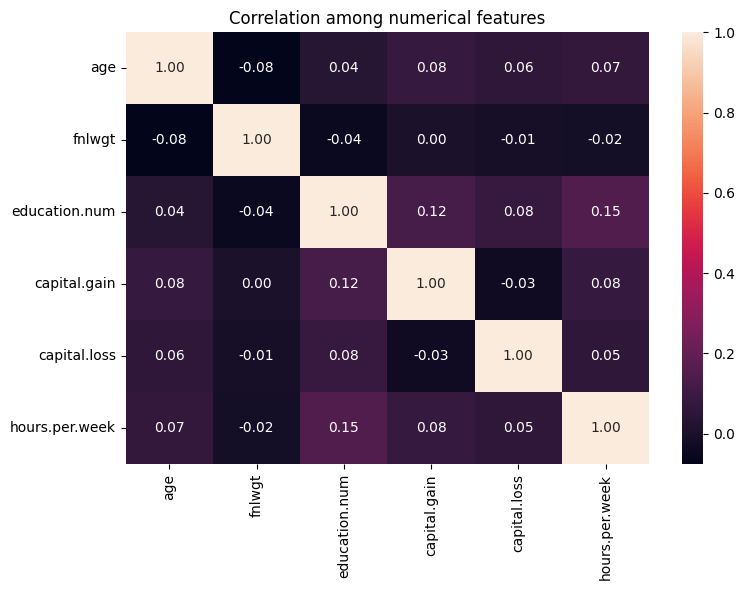

In [ ]:

# =========================
# 1. Input / output profiling for the audit report
# =========================

audit_feature_profile = pd.DataFrame({
    "feature": audit_raw_df.columns,
    "dtype": [str(audit_raw_df[c].dtype) for c in audit_raw_df.columns],
    "pandas_null_count": [audit_raw_df[c].isna().sum() for c in audit_raw_df.columns],
    "question_mark_count": [
        (audit_raw_df[c].astype(str).str.strip() == "?").sum() if audit_raw_df[c].dtype == "object" else 0
        for c in audit_raw_df.columns
    ],
    "n_unique": [audit_raw_df[c].nunique(dropna=False) for c in audit_raw_df.columns],
})

display(Markdown("### Feature profile: data type, normal missing values, hidden '?' missing values, and cardinality"))
display(audit_feature_profile)

audit_feature_profile.to_csv(AUDIT_OUTPUT_DIR / "01_feature_profile.csv", index=False)

numeric_cols = audit_raw_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in audit_raw_df.columns if c not in numeric_cols and c != "income"]

display(Markdown("### Numerical summary"))
display(audit_raw_df[numeric_cols].describe().T)

display(Markdown("### Hidden missing values encoded as '?'"))
audit_question_marks = audit_feature_profile[["feature", "question_mark_count"]].query("question_mark_count > 0")
display(audit_question_marks)

# Compact categorical distribution table: top values only, to avoid huge notebook output.
cat_dist_rows = []
for col in categorical_cols + ["income"]:
    vc = audit_raw_df[col].value_counts(dropna=False)
    for value, count in vc.head(10).items():
        cat_dist_rows.append({
            "feature": col,
            "value": value,
            "count": int(count),
            "percent": round(100 * count / len(audit_raw_df), 2)
        })
audit_cat_distribution_top10 = pd.DataFrame(cat_dist_rows)
display(Markdown("### Top categorical values by feature"))
display(audit_cat_distribution_top10)

# Numeric correlations support the Input/Output section, but they should not be overinterpreted
# because many important variables are categorical.
plt.figure(figsize=(8, 6))
sns.heatmap(audit_raw_df[numeric_cols].corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation among numerical features")
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# Compact categorical feature profiling for report
# =========================

categorical_feature_rows = []

for col in categorical_cols:
    s = audit_raw_df[col].astype(str).str.strip()

    # Count hidden missing values encoded as "?"
    question_mark_count = (s == "?").sum()

    # Distribution information
    vc = s.value_counts(dropna=False)
    top_value = vc.index[0]
    top_count = vc.iloc[0]
    top_percent = 100 * top_count / len(audit_raw_df)

    # Optional: positive income rate by most common category
    # This helps show whether the feature is predictive / socially meaningful.
    top_value_positive_rate = (
        (audit_raw_df.loc[s == top_value, "income"].astype(str).str.strip() == ">50K").mean() * 100
    )

    categorical_feature_rows.append({
        "feature": col,
        "dtype": str(audit_raw_df[col].dtype),
        "n_unique": audit_raw_df[col].nunique(dropna=False),
        "question_mark_count": int(question_mark_count),
        "question_mark_percent": round(100 * question_mark_count / len(audit_raw_df), 2),
        "most_common_value": top_value,
        "most_common_count": int(top_count),
        "most_common_percent": round(top_percent, 2),
        "positive_rate_within_most_common_value": round(top_value_positive_rate, 2)
    })

audit_categorical_profile = pd.DataFrame(categorical_feature_rows)

display(Markdown("### Compact categorical feature profile"))
display(audit_categorical_profile)

audit_categorical_profile.to_csv(
    AUDIT_OUTPUT_DIR / "02_categorical_feature_profile.csv",
    index=False
)

### Compact categorical feature profile

,feature,dtype,n_unique,question_mark_count,question_mark_percent,most_common_value,most_common_count,most_common_percent,positive_rate_within_most_common_value
0,workclass,object,9,1836,5.64,Private,22696,69.70,21.87
1,education,object,16,0,0.00,HS-grad,10501,32.25,15.95
2,marital.status,object,7,0,0.00,Married-civ-spouse,14976,45.99,44.68
3,occupation,object,15,1843,5.66,Prof-specialty,4140,12.71,44.90
4,relationship,object,6,0,0.00,Husband,13193,40.52,44.86
5,race,object,5,0,0.00,White,27816,85.43,25.59
6,sex,object,2,0,0.00,Male,21790,66.92,30.57
7,native.country,object,42,583,1.79,United-States,29170,89.59,24.58


In [ ]:

# =========================
# 2. Helper functions: reproduce the author's ADS and define audit metrics
# =========================

MISSING_COLS = ["workclass", "occupation", "native.country"]

ALL_CATEGORICAL_COLS = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]

META_COLS = [
    "_row_id",
    "age",
    "workclass",
    "education",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country",
    "income",
    "fnlwgt",
]

def age_bounds_from_raw(raw: pd.DataFrame):
    """Author's IQR-based age outlier rule, computed on the raw input data."""
    q1 = raw["age"].quantile(0.25)
    q3 = raw["age"].quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def add_derived_groups(meta: pd.DataFrame) -> pd.DataFrame:
    """Add grouped variables used for subgroup and intersectional audits."""
    out = meta.copy()
    out["age_group"] = pd.cut(
        out["age"],
        bins=[0, 24, 34, 44, 54, 64, np.inf],
        labels=["17-24", "25-34", "35-44", "45-54", "55-64", "65+"],
        right=True,
    )

    education_map = {
        "Preschool": "Less-than-HS",
        "1st-4th": "Less-than-HS",
        "5th-6th": "Less-than-HS",
        "7th-8th": "Less-than-HS",
        "9th": "Less-than-HS",
        "10th": "Less-than-HS",
        "11th": "Less-than-HS",
        "12th": "Less-than-HS",
        "HS-grad": "HS-grad",
        "Some-college": "Some-college",
        "Assoc-acdm": "Associate",
        "Assoc-voc": "Associate",
        "Bachelors": "Bachelors",
        "Masters": "Graduate",
        "Doctorate": "Graduate",
        "Prof-school": "Graduate",
    }
    out["education_group"] = out["education"].map(education_map).fillna(out["education"].astype(str))

    out["race_x_sex"] = out["race"].astype(str) + " × " + out["sex"].astype(str)
    out["marital_x_sex"] = out["marital.status"].astype(str) + " × " + out["sex"].astype(str)
    out["race_x_education"] = out["race"].astype(str) + " × " + out["education_group"].astype(str)
    return out

def build_design_matrix(
    raw: pd.DataFrame,
    *,
    include_race: bool = False,
    age_filter: bool = True,
    imputation: str = "author_mode",
):
    """
    Build the feature matrix used in the audit.

    imputation='author_mode' matches the original notebook's core choices:
      - remove IQR-defined age outliers,
      - replace workclass '?' with 'Private',
      - replace occupation '?' with 'Prof-specialty',
      - do not explicitly repair native.country '?',
      - drop race unless include_race=True,
      - one-hot encode categorical variables with drop_first=True,
      - encode income >50K as 1.

    Other imputation strategies are only sensitivity checks, not replacements for the original ADS.
    """
    df_local = raw.copy()
    # Preserve original raw row id when the full dataframe is passed.
    # This allows us to recover hidden missing values after the author's imputation removes '?'.
    if "_row_id" not in df_local.columns:
        df_local["_row_id"] = np.arange(len(df_local))

    lower, upper = age_bounds_from_raw(df_local)

    if age_filter:
        df_local = df_local[(df_local["age"] > lower) & (df_local["age"] < upper)].copy()

    if imputation == "author_mode":
        df_local["workclass"] = df_local["workclass"].replace("?", "Private")
        df_local["occupation"] = df_local["occupation"].replace("?", "Prof-specialty")
        # native.country is left unchanged to match the original notebook.
    elif imputation == "missing_category":
        for col in MISSING_COLS:
            df_local[col] = df_local[col].replace("?", "Unknown")
    elif imputation == "row_deletion":
        df_local = df_local[~df_local[MISSING_COLS].eq("?").any(axis=1)].copy()
    elif imputation == "none":
        pass
    else:
        raise ValueError("imputation must be one of: author_mode, missing_category, row_deletion, none")

    meta = df_local[META_COLS].copy().reset_index(drop=True)

    y = (df_local["income"].astype(str).str.strip() == ">50K").astype(int).to_numpy()

    feature_df = df_local.drop(columns=["income", "_row_id"])

    if not include_race and "race" in feature_df.columns:
        feature_df = feature_df.drop(columns=["race"])

    categorical_for_encoding = [c for c in ALL_CATEGORICAL_COLS if c in feature_df.columns]
    X = pd.get_dummies(feature_df, columns=categorical_for_encoding, drop_first=True)
    X = X.astype(float).reset_index(drop=True)

    return X, y, meta, (lower, upper)

def safe_div(num, den):
    return np.nan if den == 0 else num / den

def binary_metrics(y_true, y_pred, y_score=None) -> dict:
    """Return accuracy and fairness-relevant binary classification metrics."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    out = {
        "n": len(y_true),
        "positives": int(y_true.sum()),
        "negatives": int((y_true == 0).sum()),
        "predicted_positive": int(y_pred.sum()),
        "base_rate": safe_div(y_true.sum(), len(y_true)),
        "selection_rate": safe_div(y_pred.sum(), len(y_pred)),
        "accuracy": safe_div(tp + tn, len(y_true)),
        "balanced_accuracy": np.nanmean([safe_div(tp, tp + fn), safe_div(tn, tn + fp)]),
        "precision": safe_div(tp, tp + fp),
        "recall_tpr": safe_div(tp, tp + fn),  # Equal opportunity uses TPR/recall.
        "f1": safe_div(2 * tp, 2 * tp + fp + fn),
        "fpr": safe_div(fp, fp + tn),
        "fnr": safe_div(fn, fn + tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
        out["average_precision"] = average_precision_score(y_true, y_score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan

    return out

def fit_evaluate_ads(
    raw: pd.DataFrame,
    *,
    include_race: bool = False,
    age_filter: bool = True,
    imputation: str = "author_mode",
    test_size: float = 0.2,
    random_state: int = RANDOM_STATE,
    author_test_scaling: bool = True,
):
    """
    Fit and evaluate a logistic-regression ADS.

    author_test_scaling=True reproduces the original notebook's scaling behavior:
    it fits StandardScaler separately on X_train_raw and X_test_raw. This is not best practice,
    but it is kept for baseline auditing of the author's implementation.
    """
    X, y, meta, age_bounds = build_design_matrix(
        raw,
        include_race=include_race,
        age_filter=age_filter,
        imputation=imputation,
    )

    X_train_raw, X_test_raw, y_train, y_test, meta_train, meta_test = train_test_split(
        X,
        y,
        meta,
        test_size=test_size,
        random_state=random_state,
    )

    scaler_train = StandardScaler()
    X_train = scaler_train.fit_transform(X_train_raw)

    if author_test_scaling:
        scaler_test = StandardScaler()
        X_test = scaler_test.fit_transform(X_test_raw)
    else:
        scaler_test = None
        X_test = scaler_train.transform(X_test_raw)

    model = LogisticRegression(C=100, random_state=0, max_iter=1000, solver=AUDIT_LR_SOLVER)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    return {
        "X": X,
        "y": y,
        "meta": meta,
        "feature_names": X.columns.tolist(),
        "age_bounds": age_bounds,
        "X_train_raw": X_train_raw.reset_index(drop=True),
        "X_test_raw": X_test_raw.reset_index(drop=True),
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "meta_train": meta_train.reset_index(drop=True),
        "meta_test": meta_test.reset_index(drop=True),
        "scaler_train": scaler_train,
        "scaler_test": scaler_test,
        "model": model,
        "y_pred": y_pred,
        "y_score": y_score,
        "metrics": binary_metrics(y_test, y_pred, y_score),
        "settings": {
            "include_race": include_race,
            "age_filter": age_filter,
            "imputation": imputation,
            "author_test_scaling": author_test_scaling,
        },
    }

def subgroup_metrics(
    meta: pd.DataFrame,
    group_col: str,
    y_true,
    y_pred,
    y_score=None,
    *,
    min_n: int = 1,
) -> pd.DataFrame:
    """Compute metrics by one subgroup column."""
    tmp = add_derived_groups(meta).reset_index(drop=True)
    tmp["_y_true"] = np.asarray(y_true).astype(int)
    tmp["_y_pred"] = np.asarray(y_pred).astype(int)
    if y_score is not None:
        tmp["_y_score"] = np.asarray(y_score)

    rows = []
    for group_value, g in tmp.groupby(group_col, dropna=False, observed=True):
        if len(g) < min_n:
            continue
        score = g["_y_score"].to_numpy() if "_y_score" in g.columns else None
        m = binary_metrics(g["_y_true"].to_numpy(), g["_y_pred"].to_numpy(), score)
        m.update({
            "attribute": group_col,
            "group": str(group_value),
        })
        rows.append(m)

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    metric_order = [
        "attribute", "group", "n", "positives", "base_rate", "selection_rate",
        "accuracy", "balanced_accuracy", "precision", "recall_tpr", "f1",
        "fpr", "fnr", "tn", "fp", "fn", "tp", "roc_auc", "average_precision"
    ]
    return out[[c for c in metric_order if c in out.columns]].sort_values(
        ["attribute", "n"], ascending=[True, False]
    ).reset_index(drop=True)

def fairness_gap_summary(group_table: pd.DataFrame, attribute_name: str) -> pd.DataFrame:
    """
    Summarize fairness gaps across groups:
      - Statistical parity gap: max-min predicted positive rate.
      - Equal opportunity gap: max-min TPR/recall.
      - FPR gap: max-min false positive rate.
      - FNR gap: max-min false negative rate.
      - Accuracy gap: max-min accuracy.
    """
    if group_table.empty:
        return pd.DataFrame()

    metric_map = {
        "statistical_parity_gap_selection_rate": "selection_rate",
        "equal_opportunity_gap_tpr": "recall_tpr",
        "false_positive_rate_gap": "fpr",
        "false_negative_rate_gap": "fnr",
        "accuracy_gap": "accuracy",
    }

    rows = []
    for fairness_metric, metric_col in metric_map.items():
        valid = group_table.dropna(subset=[metric_col]).copy()
        if valid.empty:
            continue

        ref = valid.sort_values("n", ascending=False).iloc[0]
        min_row = valid.loc[valid[metric_col].idxmin()]
        max_row = valid.loc[valid[metric_col].idxmax()]
        max_value = max_row[metric_col]
        min_value = min_row[metric_col]

        row = {
            "attribute": attribute_name,
            "fairness_metric": fairness_metric,
            "metric_column": metric_col,
            "max_minus_min_gap": max_value - min_value,
            "min_group": min_row["group"],
            "min_value": min_value,
            "max_group": max_row["group"],
            "max_value": max_value,
            "reference_group_largest_n": ref["group"],
            "reference_value": ref[metric_col],
            "largest_abs_gap_from_reference": (valid[metric_col] - ref[metric_col]).abs().max(),
        }

        if metric_col == "selection_rate":
            row["disparate_impact_ratio_min_over_max"] = safe_div(min_value, max_value)
        else:
            row["disparate_impact_ratio_min_over_max"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["Actual <=50K", "Actual >50K"], columns=["Pred <=50K", "Pred >50K"])
    display(Markdown(f"### {title}"))
    display(cm_df)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Baseline reproduction of the original ADS

- Race is dropped, following the author's stated design choice.
- Age outliers are removed using the author's IQR rule.
- `workclass='?'` is replaced by `Private`; `occupation='?'` is replaced by `Prof-specialty`.
- `native.country='?'` is not explicitly handled before one-hot encoding.
- Logistic Regression uses the tuned setting `C=100`.
- Test features are scaled with a separately fitted scaler, matching the original notebook's implementation behavior.

Author age rule keeps ages strictly between -2.00 and 78.00.
Rows after author age filtering: 32395 / 32561
Number of model features after preprocessing: 94


,baseline_value
n,6479.000000
positives,1573.000000
negatives,4906.000000
predicted_positive,1250.000000
base_rate,0.242784
selection_rate,0.192931
accuracy,0.850440
balanced_accuracy,0.761741
precision,0.741600
recall_tpr,0.589320


### Baseline confusion matrix: original ADS reproduction

,Pred <=50K,Pred >50K
Actual <=50K,4583,323
Actual >50K,646,927


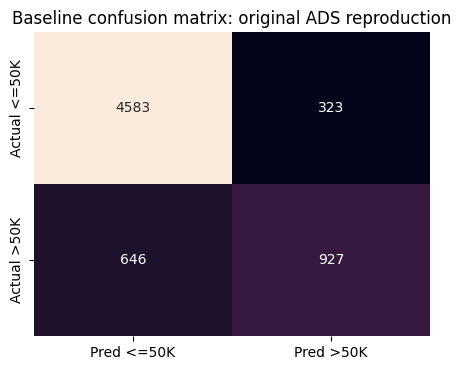

In [ ]:

# =========================
# 3. Baseline reproduction: audit the original ADS as-is
# =========================

audit_baseline = fit_evaluate_ads(
    audit_raw_df,
    include_race=False,
    age_filter=True,
    imputation="author_mode",
    author_test_scaling=True,
)

display(Markdown("## Baseline reproduction of the original ADS"))
display(Markdown(
    "- Race is dropped, following the author's stated design choice.\n"
    "- Age outliers are removed using the author's IQR rule.\n"
    "- `workclass='?'` is replaced by `Private`; `occupation='?'` is replaced by `Prof-specialty`.\n"
    "- `native.country='?'` is not explicitly handled before one-hot encoding.\n"
    "- Logistic Regression uses the tuned setting `C=100`.\n"
    "- Test features are scaled with a separately fitted scaler, matching the original notebook's implementation behavior."
))

lower_age, upper_age = audit_baseline["age_bounds"]
print(f"Author age rule keeps ages strictly between {lower_age:.2f} and {upper_age:.2f}.")
print(f"Rows after author age filtering: {len(audit_baseline['y'])} / {len(audit_raw_df)}")
print(f"Number of model features after preprocessing: {len(audit_baseline['feature_names'])}")

audit_baseline_metrics = pd.DataFrame([audit_baseline["metrics"]]).T.rename(columns={0: "baseline_value"})
display(audit_baseline_metrics)

show_confusion_matrix(
    audit_baseline["y_test"],
    audit_baseline["y_pred"],
    "Baseline confusion matrix: original ADS reproduction"
)

audit_baseline_metrics.to_csv(AUDIT_OUTPUT_DIR / "02_baseline_overall_metrics.csv")


In [ ]:

# =========================
# 4. Implementation / validation audit: global accuracy is not enough
# =========================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score

# Compare the author's separate test scaling to a conventional train-scaler transform.
# This is an implementation audit, not a replacement for the original result.
audit_author_scaling = audit_baseline
audit_train_scaler_eval = fit_evaluate_ads(
    audit_raw_df,
    include_race=False,
    age_filter=True,
    imputation="author_mode",
    author_test_scaling=False,
)

scaling_rows = []
for label, res in [
    ("author_separate_test_scaler_baseline", audit_author_scaling),
    ("train_scaler_transform_test_sensitivity", audit_train_scaler_eval),
]:
    row = {"setting": label}
    row.update(res["metrics"])
    scaling_rows.append(row)

audit_scaling_comparison = pd.DataFrame(scaling_rows)
display(Markdown("### Implementation sensitivity: test-set scaling behavior"))
display(audit_scaling_comparison[[
    "setting", "accuracy", "balanced_accuracy", "precision", "recall_tpr", "f1", "fpr", "fnr", "roc_auc", "average_precision"
]])

audit_scaling_comparison.to_csv(AUDIT_OUTPUT_DIR / "03_scaling_sensitivity.csv", index=False)

# Cross-validation validates whether the baseline-style logistic model is stable across folds.
# This uses proper train-fold scaling inside a Pipeline, so it is a validation audit rather than an exact reproduction
# of the author's separate-test-scaler behavior.
cv_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=100, random_state=0, max_iter=1000, solver=AUDIT_LR_SOLVER)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall_tpr": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}
cv_results = cross_validate(
    cv_pipe,
    audit_baseline["X"],
    audit_baseline["y"],
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

audit_cv_validation = pd.DataFrame([
    {
        "metric": metric_name.replace("test_", ""),
        "mean_5fold": float(np.mean(values)),
        "std_5fold": float(np.std(values)),
    }
    for metric_name, values in cv_results.items()
    if metric_name.startswith("test_")
]).sort_values("metric")

display(Markdown("### 5-fold validation of baseline-style Logistic Regression"))
display(audit_cv_validation)
audit_cv_validation.to_csv(AUDIT_OUTPUT_DIR / "03b_cross_validation_metrics.csv", index=False)

display(Markdown(
    "**Interpretation note for the report:** The baseline's overall accuracy should not be treated as sufficient validation. "
    "The ADS should also be judged by balanced accuracy, recall/TPR, FNR, FPR, subgroup performance, and fairness gaps, "
    "because the target label is imbalanced and false negatives directly affect people whose actual income is `>50K`."
))


### Implementation sensitivity: test-set scaling behavior

,setting,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,roc_auc,average_precision
0,author_separate_test_scaler_baseline,0.850440,0.761741,0.741600,0.589320,0.656748,0.065838,0.410680,0.903750,0.764948
1,train_scaler_transform_test_sensitivity,0.850903,0.763990,0.739921,0.595041,0.659619,0.067061,0.404959,0.903804,0.766166


### 5-fold validation of baseline-style Logistic Regression

,metric,mean_5fold,std_5fold
0,accuracy,0.850687,0.002158
6,average_precision,0.765010,0.007534
1,balanced_accuracy,0.764007,0.004119
4,f1,0.658306,0.006149
2,precision,0.734334,0.005241
3,recall_tpr,0.596594,0.008481
5,roc_auc,0.905035,0.003120


**Interpretation note for the report:** The baseline's overall accuracy should not be treated as sufficient validation. The ADS should also be judged by balanced accuracy, recall/TPR, FNR, FPR, subgroup performance, and fairness gaps, because the target label is imbalanced and false negatives directly affect people whose actual income is `>50K`.

## Subpopulation metrics

Main metrics: accuracy, precision, recall/TPR, F1, FPR, and FNR. For this ADS, recall and FNR are especially important because a false negative means an actual `>50K` person is predicted as `<=50K`.

,attribute,group,n,positives,base_rate,selection_rate,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,tn,fp,fn,tp,roc_auc,average_precision
0,sex,Male,4376,1338,0.305759,0.247029,0.816956,0.757551,0.748381,0.604634,0.668871,0.089533,0.395366,2766,272,529,809,0.884177,0.778286
1,sex,Female,2103,235,0.111745,0.080361,0.920114,0.737413,0.698225,0.502128,0.584158,0.027302,0.497872,1817,51,117,118,0.920431,0.679128
2,race,White,5548,1408,0.253785,0.202776,0.845890,0.763399,0.745778,0.595881,0.662456,0.069082,0.404119,3854,286,569,839,0.901000,0.770128
3,race,Black,593,91,0.153457,0.107926,0.897133,0.741309,0.734375,0.516484,0.606452,0.033865,0.483516,485,17,44,47,0.934854,0.749948
4,race,Asian-Pac-Islander,223,64,0.286996,0.233184,0.802691,0.730936,0.692308,0.562500,0.620690,0.100629,0.437500,143,16,28,36,0.878538,0.739832
5,race,Amer-Indian-Eskimo,65,3,0.046154,0.076923,0.938462,0.809140,0.400000,0.666667,0.500000,0.048387,0.333333,59,3,1,2,0.919355,0.533333
6,race,Other,50,7,0.140000,0.080000,0.900000,0.702658,0.750000,0.428571,0.545455,0.023256,0.571429,42,1,4,3,0.906977,0.720489
7,workclass,Private,4969,1071,0.215536,0.158986,0.863353,0.750384,0.748101,0.551821,0.635142,0.051052,0.448179,3699,199,480,591,0.908834,0.751676
8,workclass,Self-emp-not-inc,490,143,0.291837,0.228571,0.777551,0.699049,0.651786,0.510490,0.572549,0.112392,0.489510,308,39,70,73,0.811632,0.668821
9,workclass,Local-gov,380,93,0.244737,0.234211,0.857895,0.800532,0.719101,0.688172,0.703297,0.087108,0.311828,262,25,29,64,0.926867,0.789656


## Fairness gap summary

- Statistical parity gap = max-min predicted positive rate.
- Equal opportunity gap = max-min TPR/recall.
- FPR gap = max-min false positive rate.
- FNR gap = max-min false negative rate.
- Accuracy gap = max-min accuracy.

,attribute,fairness_metric,metric_column,max_minus_min_gap,min_group,min_value,max_group,max_value,reference_group_largest_n,reference_value,largest_abs_gap_from_reference,disparate_impact_ratio_min_over_max
0,sex,statistical_parity_gap_selection_rate,selection_rate,0.166668,Female,0.080361,Male,0.247029,Male,0.247029,0.166668,0.325311
1,sex,equal_opportunity_gap_tpr,recall_tpr,0.102506,Female,0.502128,Male,0.604634,Male,0.604634,0.102506,NaN
2,sex,false_positive_rate_gap,fpr,0.062231,Female,0.027302,Male,0.089533,Male,0.089533,0.062231,NaN
3,sex,false_negative_rate_gap,fnr,0.102506,Male,0.395366,Female,0.497872,Male,0.395366,0.102506,NaN
4,sex,accuracy_gap,accuracy,0.103158,Male,0.816956,Female,0.920114,Male,0.816956,0.103158,NaN
5,race,statistical_parity_gap_selection_rate,selection_rate,0.156261,Amer-Indian-Eskimo,0.076923,Asian-Pac-Islander,0.233184,White,0.202776,0.125853,0.329882
6,race,equal_opportunity_gap_tpr,recall_tpr,0.238095,Other,0.428571,Amer-Indian-Eskimo,0.666667,White,0.595881,0.167309,NaN
7,race,false_positive_rate_gap,fpr,0.077373,Other,0.023256,Asian-Pac-Islander,0.100629,White,0.069082,0.045826,NaN
8,race,false_negative_rate_gap,fnr,0.238095,Amer-Indian-Eskimo,0.333333,Other,0.571429,White,0.404119,0.167309,NaN
9,race,accuracy_gap,accuracy,0.135771,Asian-Pac-Islander,0.802691,Amer-Indian-Eskimo,0.938462,White,0.845890,0.092571,NaN


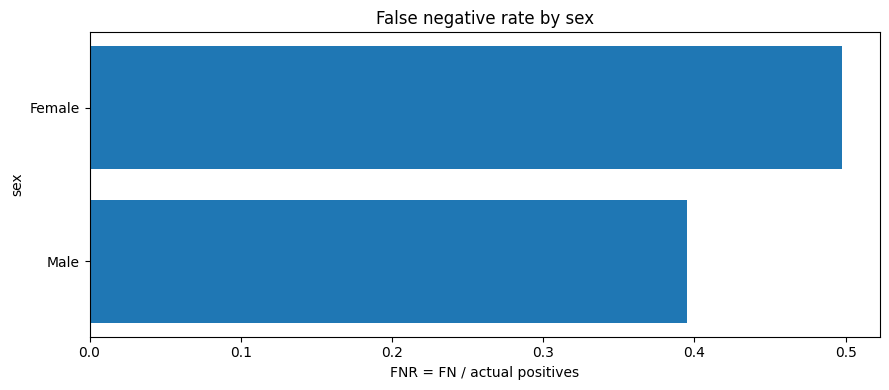

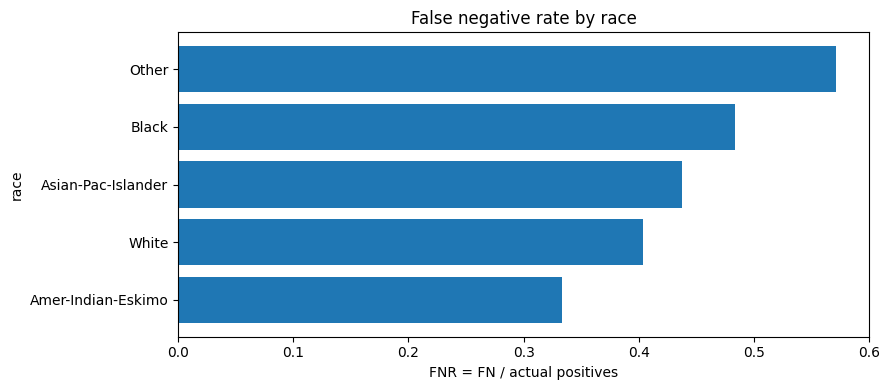

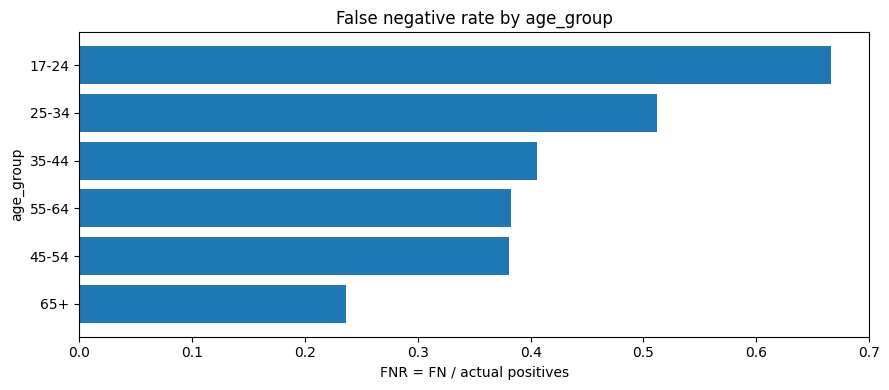

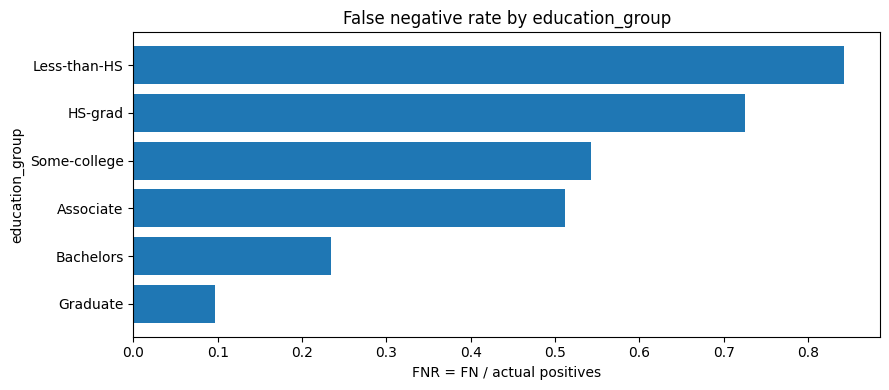

In [ ]:

# =========================
# 5. Subpopulation performance analysis
# =========================

audit_meta_test = add_derived_groups(audit_baseline["meta_test"])

single_axis_attributes = [
    "sex",
    "race",
    "workclass",
    "age_group",
    "marital.status",
    "education_group",
]

subgroup_tables = []
gap_tables = []

for attr in single_axis_attributes:
    table = subgroup_metrics(
        audit_meta_test,
        attr,
        audit_baseline["y_test"],
        audit_baseline["y_pred"],
        audit_baseline["y_score"],
        min_n=30,  # avoid unstable tiny groups in the main table
    )
    subgroup_tables.append(table)
    gap_tables.append(fairness_gap_summary(table, attr))

audit_subgroup_metrics = pd.concat(subgroup_tables, ignore_index=True)
audit_fairness_gaps = pd.concat(gap_tables, ignore_index=True)

display(Markdown("## Subpopulation metrics"))
display(Markdown(
    "Main metrics: accuracy, precision, recall/TPR, F1, FPR, and FNR. "
    "For this ADS, recall and FNR are especially important because a false negative means an actual `>50K` person is predicted as `<=50K`."
))
display(audit_subgroup_metrics)

display(Markdown("## Fairness gap summary"))
display(Markdown(
    "- Statistical parity gap = max-min predicted positive rate.\n"
    "- Equal opportunity gap = max-min TPR/recall.\n"
    "- FPR gap = max-min false positive rate.\n"
    "- FNR gap = max-min false negative rate.\n"
    "- Accuracy gap = max-min accuracy."
))
display(audit_fairness_gaps)

audit_subgroup_metrics.to_csv(AUDIT_OUTPUT_DIR / "04_single_axis_subgroup_metrics.csv", index=False)
audit_fairness_gaps.to_csv(AUDIT_OUTPUT_DIR / "05_single_axis_fairness_gaps.csv", index=False)

# Visualize the key error metric FNR for selected attributes.
for attr in ["sex", "race", "age_group", "education_group"]:
    plot_df = audit_subgroup_metrics[audit_subgroup_metrics["attribute"] == attr].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values("fnr", ascending=False)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["group"].astype(str), plot_df["fnr"])
    ax.set_title(f"False negative rate by {attr}")
    ax.set_xlabel("FNR = FN / actual positives")
    ax.set_ylabel(attr)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


## Intersectional subgroup metrics

Intersectional groups can reveal compounded disadvantages that are hidden when race, sex, education, or marital status are analyzed separately.

,attribute,group,n,positives,base_rate,selection_rate,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,tn,fp,fn,tp,roc_auc,average_precision
14,marital_x_sex,Widowed × Female,172,12,0.069767,0.011628,0.941860,0.583333,1.000000,0.166667,0.285714,0.000000,0.833333,160,0,10,2,0.703125,0.363903
9,marital_x_sex,Never-married × Male,1150,47,0.040870,0.014783,0.960000,0.592118,0.529412,0.191489,0.281250,0.007253,0.808511,1095,8,38,9,0.873401,0.411993
19,marital_x_sex,Widowed × Male,35,5,0.142857,0.057143,0.857143,0.583333,0.500000,0.200000,0.285714,0.033333,0.800000,29,1,4,1,0.946667,0.711667
11,marital_x_sex,Divorced × Female,514,40,0.077821,0.021401,0.935798,0.610390,0.818182,0.225000,0.352941,0.004219,0.775000,472,2,31,9,0.827637,0.418728
10,marital_x_sex,Never-married × Female,907,37,0.040794,0.011025,0.968026,0.621047,0.900000,0.243243,0.382979,0.001149,0.756757,869,1,28,9,0.951724,0.622607
16,marital_x_sex,Separated × Male,69,11,0.159420,0.043478,0.884058,0.636364,1.000000,0.272727,0.428571,0.000000,0.727273,58,0,8,3,0.929467,0.775193
12,marital_x_sex,Divorced × Male,411,62,0.150852,0.060827,0.885645,0.654127,0.800000,0.322581,0.459770,0.014327,0.677419,344,5,42,20,0.816665,0.554626
17,marital_x_sex,Married-spouse-absent × Male,55,6,0.109091,0.054545,0.909091,0.656463,0.666667,0.333333,0.444444,0.020408,0.666667,48,1,4,2,0.795918,0.526316
15,marital_x_sex,Separated × Female,125,2,0.016000,0.008000,0.992000,0.750000,1.000000,0.500000,0.666667,0.000000,0.500000,123,0,1,1,1.000000,1.000000
8,marital_x_sex,Married-civ-spouse × Male,2654,1207,0.454785,0.388470,0.740015,0.731825,0.750727,0.641259,0.691689,0.177609,0.358741,1190,257,433,774,0.818630,0.799200


## Intersectional fairness gaps

,attribute,fairness_metric,metric_column,max_minus_min_gap,min_group,min_value,max_group,max_value,reference_group_largest_n,reference_value,largest_abs_gap_from_reference,disparate_impact_ratio_min_over_max
0,race_x_sex,statistical_parity_gap_selection_rate,selection_rate,0.254867,Black × Female,0.055944,Asian-Pac-Islander × Male,0.310811,White × Male,0.254418,0.198474,0.179994
1,race_x_sex,equal_opportunity_gap_tpr,recall_tpr,0.266667,Asian-Pac-Islander × Female,0.400000,Amer-Indian-Eskimo × Male,0.666667,White × Male,0.609959,0.209959,NaN
2,race_x_sex,false_positive_rate_gap,fpr,0.122719,Black × Female,0.026217,Asian-Pac-Islander × Male,0.148936,White × Male,0.092319,0.066102,NaN
3,race_x_sex,false_negative_rate_gap,fnr,0.266667,Amer-Indian-Eskimo × Male,0.333333,Asian-Pac-Islander × Female,0.600000,White × Male,0.390041,0.209959,NaN
4,race_x_sex,accuracy_gap,accuracy,0.183803,Asian-Pac-Islander × Male,0.756757,Black × Female,0.940559,White × Male,0.814449,0.126110,NaN
5,marital_x_sex,statistical_parity_gap_selection_rate,selection_rate,0.424779,Married-spouse-absent × Female,0.000000,Married-civ-spouse × Female,0.424779,Married-civ-spouse × Male,0.388470,0.388470,0.000000
6,marital_x_sex,equal_opportunity_gap_tpr,recall_tpr,0.509390,Widowed × Female,0.166667,Married-civ-spouse × Female,0.676056,Married-civ-spouse × Male,0.641259,0.474593,NaN
7,marital_x_sex,false_positive_rate_gap,fpr,0.243655,Widowed × Female,0.000000,Married-civ-spouse × Female,0.243655,Married-civ-spouse × Male,0.177609,0.177609,NaN
8,marital_x_sex,false_negative_rate_gap,fnr,0.509390,Married-civ-spouse × Female,0.323944,Widowed × Female,0.833333,Married-civ-spouse × Male,0.358741,0.474593,NaN
9,marital_x_sex,accuracy_gap,accuracy,0.277286,Married-civ-spouse × Female,0.722714,Married-spouse-absent × Female,1.000000,Married-civ-spouse × Male,0.740015,0.259985,NaN


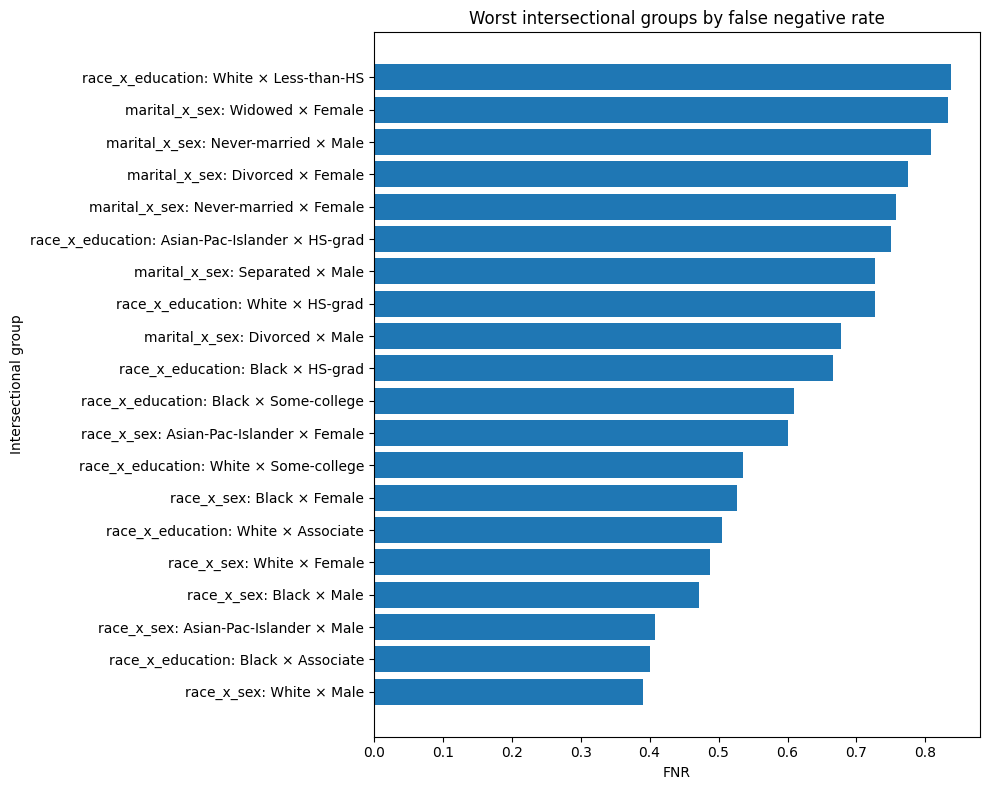

In [ ]:

# =========================
# 6. Intersectional fairness analysis
# =========================

intersectional_attributes = [
    "race_x_sex",
    "marital_x_sex",
    "race_x_education",
]

intersectional_tables = []
intersectional_gaps = []

for attr in intersectional_attributes:
    table = subgroup_metrics(
        audit_meta_test,
        attr,
        audit_baseline["y_test"],
        audit_baseline["y_pred"],
        audit_baseline["y_score"],
        min_n=30,
    )
    intersectional_tables.append(table)
    intersectional_gaps.append(fairness_gap_summary(table, attr))

audit_intersectional_metrics = pd.concat(intersectional_tables, ignore_index=True)
audit_intersectional_gaps = pd.concat(intersectional_gaps, ignore_index=True)

display(Markdown("## Intersectional subgroup metrics"))
display(Markdown(
    "Intersectional groups can reveal compounded disadvantages that are hidden when race, sex, education, or marital status are analyzed separately."
))
display(audit_intersectional_metrics.sort_values(["attribute", "fnr"], ascending=[True, False]))

display(Markdown("## Intersectional fairness gaps"))
display(audit_intersectional_gaps)

audit_intersectional_metrics.to_csv(AUDIT_OUTPUT_DIR / "06_intersectional_metrics.csv", index=False)
audit_intersectional_gaps.to_csv(AUDIT_OUTPUT_DIR / "07_intersectional_fairness_gaps.csv", index=False)

# Plot worst intersectional groups by FNR, restricted to groups with enough actual positives.
plot_intersections = audit_intersectional_metrics[
    (audit_intersectional_metrics["positives"] >= 10) & audit_intersectional_metrics["fnr"].notna()
].copy()

if not plot_intersections.empty:
    worst = plot_intersections.sort_values("fnr", ascending=False).head(20)
    worst = worst.copy()
    worst["label"] = worst["attribute"].astype(str) + ": " + worst["group"].astype(str)
    fig, ax = plt.subplots(figsize=(10, max(5, 0.4 * len(worst))))
    ax.barh(worst["label"], worst["fnr"])
    ax.set_title("Worst intersectional groups by false negative rate")
    ax.set_xlabel("FNR")
    ax.set_ylabel("Intersectional group")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No intersectional groups had at least 10 positive examples for a stable FNR plot.")


In [ ]:

# =========================
# 7. Debunking "fairness through unawareness": race removal and proxy analysis
# =========================

audit_no_race = audit_baseline
audit_with_race = fit_evaluate_ads(
    audit_raw_df,
    include_race=True,
    age_filter=True,
    imputation="author_mode",
    author_test_scaling=True,
)

race_comparison_rows = []
for label, res in [("without_race_original_setting", audit_no_race), ("with_race_sensitivity_setting", audit_with_race)]:
    row = {"model_setting": label}
    row.update(res["metrics"])
    race_comparison_rows.append(row)

audit_race_inclusion_comparison = pd.DataFrame(race_comparison_rows)
display(Markdown("## Model comparison: original no-race setting vs race-included sensitivity setting"))
display(audit_race_inclusion_comparison[[
    "model_setting", "accuracy", "balanced_accuracy", "precision", "recall_tpr", "f1", "fpr", "fnr", "roc_auc", "average_precision"
]])

# Compare fairness gaps by race and sex for both settings.
race_gap_rows = []
for model_label, res in [("without_race_original_setting", audit_no_race), ("with_race_sensitivity_setting", audit_with_race)]:
    meta_test_local = add_derived_groups(res["meta_test"])
    for attr in ["race", "sex"]:
        table = subgroup_metrics(meta_test_local, attr, res["y_test"], res["y_pred"], res["y_score"], min_n=30)
        gaps = fairness_gap_summary(table, attr)
        gaps.insert(0, "model_setting", model_label)
        race_gap_rows.append(gaps)

audit_race_fairness_gap_comparison = pd.concat(race_gap_rows, ignore_index=True)
display(Markdown("### Fairness gap comparison for race and sex"))
display(audit_race_fairness_gap_comparison)

audit_race_inclusion_comparison.to_csv(AUDIT_OUTPUT_DIR / "08_race_inclusion_model_comparison.csv", index=False)
audit_race_fairness_gap_comparison.to_csv(AUDIT_OUTPUT_DIR / "09_race_inclusion_fairness_gaps.csv", index=False)

display(Markdown(
    "**Interpretation note:** If dropping race does not reduce race-based gaps, this supports the critique that 'fairness through unawareness' is insufficient. "
    "Other variables may still encode race-related information through social and historical patterns."
))


## Model comparison: original no-race setting vs race-included sensitivity setting

,model_setting,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,roc_auc,average_precision
0,without_race_original_setting,0.850440,0.761741,0.741600,0.589320,0.656748,0.065838,0.410680,0.903750,0.764948
1,with_race_sensitivity_setting,0.850286,0.760559,0.742949,0.586141,0.655295,0.065022,0.413859,0.903612,0.764830


### Fairness gap comparison for race and sex

,model_setting,attribute,fairness_metric,metric_column,max_minus_min_gap,min_group,min_value,max_group,max_value,reference_group_largest_n,reference_value,largest_abs_gap_from_reference,disparate_impact_ratio_min_over_max
0,without_race_original_setting,race,statistical_parity_gap_selection_rate,selection_rate,0.156261,Amer-Indian-Eskimo,0.076923,Asian-Pac-Islander,0.233184,White,0.202776,0.125853,0.329882
1,without_race_original_setting,race,equal_opportunity_gap_tpr,recall_tpr,0.238095,Other,0.428571,Amer-Indian-Eskimo,0.666667,White,0.595881,0.167309,NaN
2,without_race_original_setting,race,false_positive_rate_gap,fpr,0.077373,Other,0.023256,Asian-Pac-Islander,0.100629,White,0.069082,0.045826,NaN
3,without_race_original_setting,race,false_negative_rate_gap,fnr,0.238095,Amer-Indian-Eskimo,0.333333,Other,0.571429,White,0.404119,0.167309,NaN
4,without_race_original_setting,race,accuracy_gap,accuracy,0.135771,Asian-Pac-Islander,0.802691,Amer-Indian-Eskimo,0.938462,White,0.845890,0.092571,NaN
5,without_race_original_setting,sex,statistical_parity_gap_selection_rate,selection_rate,0.166668,Female,0.080361,Male,0.247029,Male,0.247029,0.166668,0.325311
6,without_race_original_setting,sex,equal_opportunity_gap_tpr,recall_tpr,0.102506,Female,0.502128,Male,0.604634,Male,0.604634,0.102506,NaN
7,without_race_original_setting,sex,false_positive_rate_gap,fpr,0.062231,Female,0.027302,Male,0.089533,Male,0.089533,0.062231,NaN
8,without_race_original_setting,sex,false_negative_rate_gap,fnr,0.102506,Male,0.395366,Female,0.497872,Male,0.395366,0.102506,NaN
9,without_race_original_setting,sex,accuracy_gap,accuracy,0.103158,Male,0.816956,Female,0.920114,Male,0.816956,0.103158,NaN


**Interpretation note:** If dropping race does not reduce race-based gaps, this supports the critique that 'fairness through unawareness' is insufficient. Other variables may still encode race-related information through social and historical patterns.

In [ ]:

# =========================
# 8. Proxy discrimination audit: Cramer's V and race predictability
# =========================

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Bias-corrected Cramer's V for association between two categorical variables."""
    confusion = pd.crosstab(x, y)
    if confusion.size == 0:
        return np.nan

    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.to_numpy().sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion.shape

    # Bias correction.
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

# Use the age-filtered, author-imputed data because this is the population actually used by the original ADS.
_, _, audit_author_population_meta, _ = build_design_matrix(
    audit_raw_df,
    include_race=False,
    age_filter=True,
    imputation="author_mode",
)
audit_author_population_meta = add_derived_groups(audit_author_population_meta)

proxy_candidate_features = [
    "education",
    "education_group",
    "occupation",
    "workclass",
    "marital.status",
    "relationship",
    "sex",
    "native.country",
    "age_group",
]

cramer_rows = []
for feature in proxy_candidate_features:
    cramer_rows.append({
        "feature": feature,
        "association_with_race_cramers_v": cramers_v(audit_author_population_meta[feature], audit_author_population_meta["race"]),
        "n_unique": audit_author_population_meta[feature].nunique(dropna=False),
    })

audit_cramers_v = pd.DataFrame(cramer_rows).sort_values("association_with_race_cramers_v", ascending=False)
display(Markdown("## Cramer's V: association between race and potential proxy variables"))
display(audit_cramers_v)

audit_cramers_v.to_csv(AUDIT_OUTPUT_DIR / "10_cramers_v_proxy_race.csv", index=False)

# Show conditional distributions for the strongest categorical proxies.
top_proxy_features = audit_cramers_v["feature"].head(3).tolist()
for feature in top_proxy_features:
    display(Markdown(f"### Conditional distribution: {feature} by race"))
    cond = pd.crosstab(
        audit_author_population_meta[feature],
        audit_author_population_meta["race"],
        normalize="columns",
    ).round(3)
    display(cond)

# Additional proxy test: can non-race features predict whether someone is White?
# A high AUC means race is recoverable from other variables, so dropping race alone does not remove race information.
X_proxy, _, proxy_meta, _ = build_design_matrix(
    audit_raw_df,
    include_race=False,
    age_filter=True,
    imputation="author_mode",
)
y_proxy = (proxy_meta["race"] == "White").astype(int).to_numpy()

X_proxy_train, X_proxy_test, y_proxy_train, y_proxy_test = train_test_split(
    X_proxy,
    y_proxy,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_proxy,
)

proxy_scaler = StandardScaler()
X_proxy_train_scaled = proxy_scaler.fit_transform(X_proxy_train)
X_proxy_test_scaled = proxy_scaler.transform(X_proxy_test)

proxy_model = LogisticRegression(max_iter=1000, random_state=0, solver=AUDIT_LR_SOLVER)
proxy_model.fit(X_proxy_train_scaled, y_proxy_train)

proxy_prob = proxy_model.predict_proba(X_proxy_test_scaled)[:, 1]
proxy_pred = proxy_model.predict(X_proxy_test_scaled)

audit_race_proxy_predictability = pd.DataFrame([{
    "target": "race == White",
    "accuracy": (proxy_pred == y_proxy_test).mean(),
    "roc_auc": roc_auc_score(y_proxy_test, proxy_prob),
    "positive_rate_white": y_proxy.mean(),
}])

display(Markdown("## Race proxy predictability from non-race features"))
display(audit_race_proxy_predictability)

audit_race_proxy_predictability.to_csv(AUDIT_OUTPUT_DIR / "11_race_proxy_predictability.csv", index=False)


## Cramer's V: association between race and potential proxy variables

,feature,association_with_race_cramers_v,n_unique
7,native.country,0.408352,42
6,sex,0.117451,2
5,relationship,0.097436,6
4,marital.status,0.083133,7
2,occupation,0.075103,14
0,education,0.071899,16
1,education_group,0.063633,6
3,workclass,0.052984,8
8,age_group,0.025317,6


### Conditional distribution: native.country by race

race,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
native.country,,,,,
?,0.000,0.080,0.031,0.066,0.014
Cambodia,0.000,0.017,0.000,0.000,0.000
Canada,0.000,0.001,0.000,0.004,0.004
China,0.000,0.071,0.000,0.000,0.000
Columbia,0.003,0.000,0.000,0.026,0.002
Cuba,0.000,0.000,0.001,0.007,0.003
Dominican-Republic,0.000,0.001,0.004,0.066,0.001
Ecuador,0.000,0.000,0.000,0.033,0.001
El-Salvador,0.000,0.000,0.000,0.015,0.004


### Conditional distribution: sex by race

race,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
sex,,,,,
Female,0.382,0.335,0.497,0.402,0.311
Male,0.618,0.665,0.503,0.598,0.689


### Conditional distribution: relationship by race

race,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
relationship,,,,,
Husband,0.298,0.395,0.215,0.295,0.429
Not-in-family,0.259,0.204,0.259,0.269,0.256
Other-relative,0.042,0.079,0.053,0.103,0.025
Own-child,0.155,0.167,0.178,0.137,0.154
Unmarried,0.184,0.087,0.246,0.137,0.090
Wife,0.061,0.067,0.049,0.059,0.047


## Race proxy predictability from non-race features

,target,accuracy,roc_auc,positive_rate_white
0,race == White,0.877605,0.763091,0.854052


In [ ]:

# =========================
# 9. Auditing the author's imputation strategy
# =========================

# Recover original hidden '?' values for the baseline test rows using _row_id.
raw_with_id = audit_raw_df.copy()
raw_with_id["_row_id"] = np.arange(len(raw_with_id))
raw_lookup = raw_with_id.set_index("_row_id")

imputation_meta_test = audit_meta_test.copy()
for col in MISSING_COLS:
    imputation_meta_test[f"original_{col}"] = imputation_meta_test["_row_id"].map(raw_lookup[col])
    imputation_meta_test[f"missing_original_{col}"] = (imputation_meta_test[f"original_{col}"] == "?")

imputation_meta_test["any_original_missing"] = imputation_meta_test[[f"missing_original_{c}" for c in MISSING_COLS]].any(axis=1)

missing_group_tables = []
for attr in ["any_original_missing"] + [f"missing_original_{c}" for c in MISSING_COLS]:
    table = subgroup_metrics(
        imputation_meta_test,
        attr,
        audit_baseline["y_test"],
        audit_baseline["y_pred"],
        audit_baseline["y_score"],
        min_n=1,
    )
    missing_group_tables.append(table)

audit_missingness_performance = pd.concat(missing_group_tables, ignore_index=True)
display(Markdown("## Baseline performance on rows with vs without original '?' missing values"))
display(audit_missingness_performance)

audit_missingness_performance.to_csv(AUDIT_OUTPUT_DIR / "12_missingness_performance_baseline.csv", index=False)

# Sensitivity comparison across imputation strategies.
imputation_strategy_rows = []
imputation_gap_rows = []

for strategy in ["author_mode", "missing_category", "row_deletion"]:
    res = fit_evaluate_ads(
        audit_raw_df,
        include_race=False,
        age_filter=True,
        imputation=strategy,
        author_test_scaling=True,
    )

    row = {
        "imputation_strategy": strategy,
        "n_after_preprocessing": len(res["y"]),
    }
    row.update(res["metrics"])
    imputation_strategy_rows.append(row)

    for attr in ["sex", "race"]:
        table = subgroup_metrics(
            add_derived_groups(res["meta_test"]),
            attr,
            res["y_test"],
            res["y_pred"],
            res["y_score"],
            min_n=30,
        )
        gaps = fairness_gap_summary(table, attr)
        gaps.insert(0, "imputation_strategy", strategy)
        imputation_gap_rows.append(gaps)

audit_imputation_strategy_comparison = pd.DataFrame(imputation_strategy_rows)
audit_imputation_gap_comparison = pd.concat(imputation_gap_rows, ignore_index=True)

display(Markdown("## Sensitivity comparison across imputation strategies"))
display(audit_imputation_strategy_comparison[[
    "imputation_strategy", "n_after_preprocessing", "accuracy", "balanced_accuracy", "precision",
    "recall_tpr", "f1", "fpr", "fnr", "roc_auc", "average_precision"
]])

display(Markdown("## Fairness gaps under imputation sensitivity settings"))
display(audit_imputation_gap_comparison)

audit_imputation_strategy_comparison.to_csv(AUDIT_OUTPUT_DIR / "13_imputation_strategy_comparison.csv", index=False)
audit_imputation_gap_comparison.to_csv(AUDIT_OUTPUT_DIR / "14_imputation_strategy_fairness_gaps.csv", index=False)

display(Markdown(
    "**Interpretation note:** This section does not claim that the alternative strategies are the final solution. "
    "It tests whether the author's mode imputation choice changes performance and fairness conclusions."
))


## Baseline performance on rows with vs without original '?' missing values

,attribute,group,n,positives,base_rate,selection_rate,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,tn,fp,fn,tp,roc_auc,average_precision
0,any_original_missing,False,6012,1511,0.251331,0.197771,0.846307,0.760408,0.746846,0.587690,0.657778,0.066874,0.412310,4200,301,623,888,0.902714,0.768978
1,any_original_missing,True,467,62,0.132762,0.130621,0.903640,0.787356,0.639344,0.629032,0.634146,0.054321,0.370968,383,22,23,39,0.920231,0.713692
2,missing_original_workclass,False,6120,1536,0.250980,0.197386,0.847386,0.761547,0.749172,0.589193,0.659621,0.066099,0.410807,4281,303,631,905,0.903662,0.771630
3,missing_original_workclass,True,359,37,0.103064,0.116992,0.902507,0.766241,0.523810,0.594595,0.556962,0.062112,0.405405,302,20,15,22,0.911784,0.603600
4,missing_original_occupation,False,6117,1536,0.251103,0.197482,0.847311,0.761525,0.749172,0.589193,0.659621,0.066143,0.410807,4278,303,631,905,0.903609,0.771634
5,missing_original_occupation,True,362,37,0.102210,0.116022,0.903315,0.766528,0.523810,0.594595,0.556962,0.061538,0.405405,305,20,15,22,0.912432,0.603528
6,missing_original_native.country,False,6368,1547,0.242933,0.193310,0.849560,0.760826,0.739236,0.588235,0.655148,0.066584,0.411765,4500,321,637,910,0.902954,0.762404
7,missing_original_native.country,True,111,26,0.234234,0.171171,0.900901,0.815158,0.894737,0.653846,0.755556,0.023529,0.346154,83,2,9,17,0.942081,0.898287


## Sensitivity comparison across imputation strategies

,imputation_strategy,n_after_preprocessing,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,roc_auc,average_precision
0,author_mode,32395,0.850440,0.761741,0.741600,0.589320,0.656748,0.065838,0.410680,0.903750,0.764948
1,missing_category,32395,0.852601,0.764464,0.747596,0.593134,0.661468,0.064207,0.406866,0.905517,0.768870
2,row_deletion,30042,0.848394,0.770331,0.745208,0.611803,0.671948,0.071142,0.388197,0.911511,0.782577


## Fairness gaps under imputation sensitivity settings

,imputation_strategy,attribute,fairness_metric,metric_column,max_minus_min_gap,min_group,min_value,max_group,max_value,reference_group_largest_n,reference_value,largest_abs_gap_from_reference,disparate_impact_ratio_min_over_max
0,author_mode,sex,statistical_parity_gap_selection_rate,selection_rate,0.166668,Female,0.080361,Male,0.247029,Male,0.247029,0.166668,0.325311
1,author_mode,sex,equal_opportunity_gap_tpr,recall_tpr,0.102506,Female,0.502128,Male,0.604634,Male,0.604634,0.102506,NaN
2,author_mode,sex,false_positive_rate_gap,fpr,0.062231,Female,0.027302,Male,0.089533,Male,0.089533,0.062231,NaN
3,author_mode,sex,false_negative_rate_gap,fnr,0.102506,Male,0.395366,Female,0.497872,Male,0.395366,0.102506,NaN
4,author_mode,sex,accuracy_gap,accuracy,0.103158,Male,0.816956,Female,0.920114,Male,0.816956,0.103158,NaN
5,author_mode,race,statistical_parity_gap_selection_rate,selection_rate,0.156261,Amer-Indian-Eskimo,0.076923,Asian-Pac-Islander,0.233184,White,0.202776,0.125853,0.329882
6,author_mode,race,equal_opportunity_gap_tpr,recall_tpr,0.238095,Other,0.428571,Amer-Indian-Eskimo,0.666667,White,0.595881,0.167309,NaN
7,author_mode,race,false_positive_rate_gap,fpr,0.077373,Other,0.023256,Asian-Pac-Islander,0.100629,White,0.069082,0.045826,NaN
8,author_mode,race,false_negative_rate_gap,fnr,0.238095,Amer-Indian-Eskimo,0.333333,Other,0.571429,White,0.404119,0.167309,NaN
9,author_mode,race,accuracy_gap,accuracy,0.135771,Asian-Pac-Islander,0.802691,Amer-Indian-Eskimo,0.938462,White,0.845890,0.092571,NaN


**Interpretation note:** This section does not claim that the alternative strategies are the final solution. It tests whether the author's mode imputation choice changes performance and fairness conclusions.

In [ ]:

# =========================
# 10. Auditing age-based sample selection bias and robustness
# =========================

lower_age, upper_age = age_bounds_from_raw(audit_raw_df)

age_audit_df = audit_raw_df.copy()
age_audit_df["age_filter_status"] = np.where(
    (age_audit_df["age"] > lower_age) & (age_audit_df["age"] < upper_age),
    "kept_by_author_age_filter",
    "excluded_by_author_age_filter",
)
age_audit_df["income_binary"] = (age_audit_df["income"].astype(str).str.strip() == ">50K").astype(int)

display(Markdown("## Age filter summary"))
display(pd.DataFrame({
    "lower_bound_exclusive": [lower_age],
    "upper_bound_exclusive": [upper_age],
    "rows_total": [len(age_audit_df)],
    "rows_kept": [(age_audit_df["age_filter_status"] == "kept_by_author_age_filter").sum()],
    "rows_excluded": [(age_audit_df["age_filter_status"] == "excluded_by_author_age_filter").sum()],
    "percent_excluded": [100 * (age_audit_df["age_filter_status"] == "excluded_by_author_age_filter").mean()],
}))

age_filter_distribution = age_audit_df.groupby("age_filter_status").agg(
    n=("income_binary", "size"),
    mean_age=("age", "mean"),
    min_age=("age", "min"),
    max_age=("age", "max"),
    positive_income_rate=("income_binary", "mean"),
).reset_index()

display(age_filter_distribution)

# Composition shift by sex and race.
for col in ["sex", "race", "income"]:
    display(Markdown(f"### Distribution of {col} before vs after age filtering"))
    dist = pd.crosstab(age_audit_df[col], age_audit_df["age_filter_status"], normalize="columns").round(3)
    display(dist)

# Baseline model's performance across age groups in the kept test set.
age_group_table = subgroup_metrics(
    audit_meta_test,
    "age_group",
    audit_baseline["y_test"],
    audit_baseline["y_pred"],
    audit_baseline["y_score"],
    min_n=30,
)
display(Markdown("## Baseline performance by age group among rows kept by the author's age filter"))
display(age_group_table)

# Robustness stress test: evaluate the trained baseline classifier on age-excluded rows.
# For this stress test, we apply the train scaler so the trained model receives inputs in the scale it learned.
excluded_raw = audit_raw_df[
    ~((audit_raw_df["age"] > lower_age) & (audit_raw_df["age"] < upper_age))
].copy()

if len(excluded_raw) > 0:
    X_excluded, y_excluded, meta_excluded, _ = build_design_matrix(
        excluded_raw,
        include_race=False,
        age_filter=False,
        imputation="author_mode",
    )

    X_excluded_aligned = X_excluded.reindex(columns=audit_baseline["feature_names"], fill_value=0)
    X_excluded_scaled = audit_baseline["scaler_train"].transform(X_excluded_aligned)
    y_excluded_pred = audit_baseline["model"].predict(X_excluded_scaled)
    y_excluded_score = audit_baseline["model"].predict_proba(X_excluded_scaled)[:, 1]

    excluded_metrics = pd.DataFrame([binary_metrics(y_excluded, y_excluded_pred, y_excluded_score)])
    display(Markdown("## Robustness stress test on rows excluded by the author's age filter"))
    display(excluded_metrics)

    excluded_age_subgroups = subgroup_metrics(
        add_derived_groups(meta_excluded),
        "age_group",
        y_excluded,
        y_excluded_pred,
        y_excluded_score,
        min_n=10,
    )
    display(Markdown("### Excluded-row performance by age group"))
    display(excluded_age_subgroups)
else:
    print("No rows were excluded by the author's age filter.")

# Sensitivity: compare with a model trained without age filtering.
# Again, this is not a replacement; it tests whether the preprocessing choice changes the audit conclusion.
audit_no_age_filter = fit_evaluate_ads(
    audit_raw_df,
    include_race=False,
    age_filter=False,
    imputation="author_mode",
    author_test_scaling=True,
)

age_filter_sensitivity = pd.DataFrame([
    {"setting": "author_age_filter_baseline", "n_after_preprocessing": len(audit_baseline["y"]), **audit_baseline["metrics"]},
    {"setting": "no_age_filter_sensitivity", "n_after_preprocessing": len(audit_no_age_filter["y"]), **audit_no_age_filter["metrics"]},
])

display(Markdown("## Sensitivity comparison: with vs without author age filtering"))
display(age_filter_sensitivity[[
    "setting", "n_after_preprocessing", "accuracy", "balanced_accuracy", "precision",
    "recall_tpr", "f1", "fpr", "fnr", "roc_auc", "average_precision"
]])

age_filter_distribution.to_csv(AUDIT_OUTPUT_DIR / "15_age_filter_distribution.csv", index=False)
age_group_table.to_csv(AUDIT_OUTPUT_DIR / "16_age_group_metrics_kept_test.csv", index=False)
age_filter_sensitivity.to_csv(AUDIT_OUTPUT_DIR / "17_age_filter_sensitivity.csv", index=False)


## Age filter summary

,lower_bound_exclusive,upper_bound_exclusive,rows_total,rows_kept,rows_excluded,percent_excluded
0,-2.0,78.0,32561,32395,166,0.509812


,age_filter_status,n,mean_age,min_age,max_age,positive_income_rate
0,excluded_by_author_age_filter,166,83.108434,78,90,0.180723
1,kept_by_author_age_filter,32395,38.353480,17,77,0.241117


### Distribution of sex before vs after age filtering

age_filter_status,excluded_by_author_age_filter,kept_by_author_age_filter
sex,,
Female,0.301,0.331
Male,0.699,0.669


...

,n,positives,negatives,predicted_positive,base_rate,selection_rate,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,tn,fp,fn,tp,roc_auc,average_precision
0,166,30,136,49,0.180723,0.295181,0.813253,0.808088,0.489796,0.8,0.607595,0.183824,0.2,111,25,6,24,0.922304,0.770334


### Excluded-row performance by age group

,attribute,group,n,positives,base_rate,selection_rate,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,tn,fp,fn,tp,roc_auc,average_precision
0,age_group,65+,166,30,0.180723,0.295181,0.813253,0.808088,0.489796,0.8,0.607595,0.183824,0.2,111,25,6,24,0.922304,0.770334


## Sensitivity comparison: with vs without author age filtering

,setting,n_after_preprocessing,accuracy,balanced_accuracy,precision,recall_tpr,f1,fpr,fnr,roc_auc,average_precision
0,author_age_filter_baseline,32395,0.85044,0.761741,0.741600,0.58932,0.656748,0.065838,0.41068,0.903750,0.764948
1,no_age_filter_sensitivity,32561,0.85598,0.768643,0.752396,0.60000,0.667612,0.062715,0.40000,0.909998,0.773499


## Largest logistic-regression coefficients by absolute value

,feature,coefficient_standardized_space,abs_coefficient
0,capital.gain,2.281752,2.281752
1,marital.status_Married-civ-spouse,1.069039,1.069039
2,education.num,0.584991,0.584991
3,education_Preschool,-0.572979,0.572979
4,sex_Male,0.435998,0.435998
5,hours.per.week,0.396684,0.396684
6,age,0.344420,0.344420
7,relationship_Wife,0.312345,0.312345
8,relationship_Own-child,-0.286079,0.286079
9,occupation_Exec-managerial,0.265676,0.265676


### Top positive coefficients: features increasing predicted probability of >50K

,feature,coefficient_standardized_space,abs_coefficient
0,capital.gain,2.281752,2.281752
1,marital.status_Married-civ-spouse,1.069039,1.069039
2,education.num,0.584991,0.584991
4,sex_Male,0.435998,0.435998
5,hours.per.week,0.396684,0.396684
6,age,0.344420,0.344420
7,relationship_Wife,0.312345,0.312345
9,occupation_Exec-managerial,0.265676,0.265676
10,capital.loss,0.261213,0.261213
15,relationship_Not-in-family,0.207973,0.207973


### Top negative coefficients: features decreasing predicted probability of >50K

,feature,coefficient_standardized_space,abs_coefficient
3,education_Preschool,-0.572979,0.572979
8,relationship_Own-child,-0.286079,0.286079
11,occupation_Priv-house-serv,-0.252949,0.252949
12,workclass_Self-emp-not-inc,-0.251881,0.251881
13,workclass_Private,-0.227334,0.227334
14,occupation_Other-service,-0.224106,0.224106
16,marital.status_Never-married,-0.193527,0.193527
17,occupation_Farming-fishing,-0.182372,0.182372
19,workclass_Without-pay,-0.170153,0.170153
21,workclass_State-gov,-0.148507,0.148507


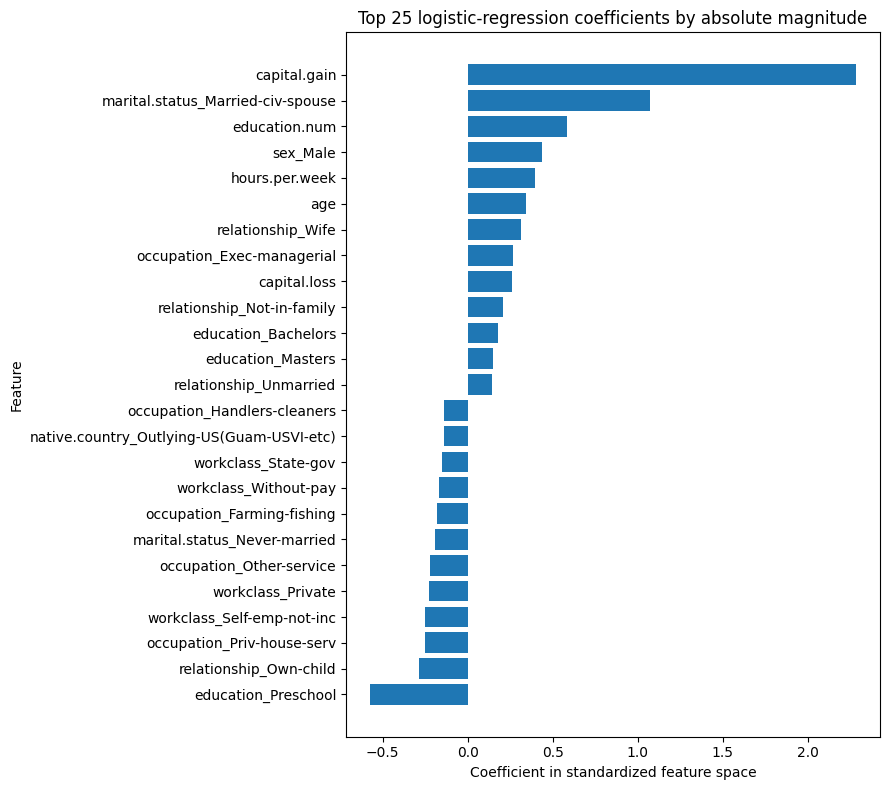

## Global feature importance from exact linear log-odds contributions

,feature,mean_abs_log_odds_contribution,mean_log_odds_contribution
29,marital.status_Married-civ-spouse,1.065940,8.005806e-17
3,capital.gain,0.612961,-4.057737e-17
2,education.num,0.432028,8.773486e-17
52,sex_Male,0.408286,-5.812435e-17
0,age,0.285925,7.265543e-17
5,hours.per.week,0.248750,1.080236e-16
49,relationship_Own-child,0.207550,-1.370857e-19
8,workclass_Private,0.192225,-1.878074e-17
47,relationship_Not-in-family,0.180489,-9.596001e-18
31,marital.status_Never-married,0.180173,5.483429e-18


## Local explanations for representative difficult/error cases

,test_row_index,feature,log_odds_contribution,age,sex,race,education,occupation,income,y_true,y_pred,score_prob_gt50k,error_type
0,1177,education.num,-1.376093,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
1,1177,occupation_Farming-fishing,-1.038027,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
2,1177,marital.status_Married-civ-spouse,-0.990566,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
3,1177,relationship_Not-in-family,0.358707,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
4,1177,native.country_United-States,-0.352154,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
5,1177,native.country_Mexico,-0.338826,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
6,1177,capital.gain,-0.334321,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
7,1177,sex_Male,0.302249,33,Male,White,7th-8th,Farming-fishing,>50K,1,0,0.001252,false_negative
8,1328,capital.gain,9.772294,55,Male,White,HS-grad,Exec-managerial,<=50K,0,1,0.999802,false_positive
9,1328,marital.status_Married-civ-spouse,-0.990566,55,Male,White,HS-grad,Exec-managerial,<=50K,0,1,0.999802,false_positive


In [ ]:

# =========================
# 11. Transparency: interpretable logistic-regression coefficients, exact linear contributions, and optional SHAP
# =========================

coef_df = pd.DataFrame({
    "feature": audit_baseline["feature_names"],
    "coefficient_standardized_space": audit_baseline["model"].coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient_standardized_space"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

display(Markdown("## Largest logistic-regression coefficients by absolute value"))
display(coef_df.head(30))

display(Markdown("### Top positive coefficients: features increasing predicted probability of >50K"))
display(coef_df.sort_values("coefficient_standardized_space", ascending=False).head(20))

display(Markdown("### Top negative coefficients: features decreasing predicted probability of >50K"))
display(coef_df.sort_values("coefficient_standardized_space", ascending=True).head(20))

coef_df.to_csv(AUDIT_OUTPUT_DIR / "18_logistic_regression_coefficients.csv", index=False)

top_coef = coef_df.head(25).sort_values("coefficient_standardized_space")
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_coef["feature"].astype(str), top_coef["coefficient_standardized_space"])
ax.set_title("Top 25 logistic-regression coefficients by absolute magnitude")
ax.set_xlabel("Coefficient in standardized feature space")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

# Exact linear contribution audit.
# For a standardized linear logistic model, beta_j * x_j is each feature's direct contribution to log-odds.
# This always runs, so the notebook still has local/global interpretability even if SHAP is unavailable.
contrib_matrix = audit_baseline["X_test"] * audit_baseline["model"].coef_[0]
contrib_df = pd.DataFrame(contrib_matrix, columns=audit_baseline["feature_names"])

audit_linear_contribution_importance = pd.DataFrame({
    "feature": audit_baseline["feature_names"],
    "mean_abs_log_odds_contribution": contrib_df.abs().mean(axis=0).values,
    "mean_log_odds_contribution": contrib_df.mean(axis=0).values,
}).sort_values("mean_abs_log_odds_contribution", ascending=False)

display(Markdown("## Global feature importance from exact linear log-odds contributions"))
display(audit_linear_contribution_importance.head(30))
audit_linear_contribution_importance.to_csv(AUDIT_OUTPUT_DIR / "18b_linear_contribution_importance.csv", index=False)

# Local explanations for representative high-confidence errors and borderline cases.
local_explain_base = audit_baseline["meta_test"].copy().reset_index(drop=True)
local_explain_base["y_true"] = audit_baseline["y_test"]
local_explain_base["y_pred"] = audit_baseline["y_pred"]
local_explain_base["score_prob_gt50k"] = audit_baseline["y_score"]
local_explain_base["error_type"] = np.select(
    [
        (local_explain_base["y_true"] == 1) & (local_explain_base["y_pred"] == 0),
        (local_explain_base["y_true"] == 0) & (local_explain_base["y_pred"] == 1),
        (local_explain_base["y_true"] == local_explain_base["y_pred"]),
    ],
    ["false_negative", "false_positive", "correct"],
    default="other",
)
local_explain_base["distance_from_threshold"] = (local_explain_base["score_prob_gt50k"] - 0.5).abs()

def top_linear_contributions_for_row(row_index: int, top_k: int = 8) -> pd.DataFrame:
    row_contrib = contrib_df.iloc[row_index].sort_values(key=lambda s: s.abs(), ascending=False).head(top_k)
    return pd.DataFrame({
        "feature": row_contrib.index,
        "log_odds_contribution": row_contrib.values,
    })

example_indices = []
# Most confident false negative: actual >50K but predicted <=50K with lowest >50K probability.
fn_candidates = local_explain_base[local_explain_base["error_type"] == "false_negative"].sort_values("score_prob_gt50k", ascending=True)
fp_candidates = local_explain_base[local_explain_base["error_type"] == "false_positive"].sort_values("score_prob_gt50k", ascending=False)
border_candidates = local_explain_base.sort_values("distance_from_threshold", ascending=True)
for candidates in [fn_candidates, fp_candidates, border_candidates]:
    for idx in candidates.index[:1]:
        if idx not in example_indices:
            example_indices.append(idx)

audit_local_explanations = []
for idx in example_indices:
    header = local_explain_base.loc[idx, ["age", "sex", "race", "education", "occupation", "income", "y_true", "y_pred", "score_prob_gt50k", "error_type"]].to_dict()
    top_parts = top_linear_contributions_for_row(idx, top_k=8)
    top_parts.insert(0, "test_row_index", idx)
    for key, value in header.items():
        top_parts[key] = value
    audit_local_explanations.append(top_parts)

if audit_local_explanations:
    audit_local_explanations = pd.concat(audit_local_explanations, ignore_index=True)
    display(Markdown("## Local explanations for representative difficult/error cases"))
    display(audit_local_explanations)
    audit_local_explanations.to_csv(AUDIT_OUTPUT_DIR / "18c_local_linear_explanations.csv", index=False)

# Optional SHAP explanation.
# This tries to run automatically if SHAP is installed. If it is unavailable, the notebook does not fail;
# the coefficient and linear-contribution tables above still provide interpretable global/local explanations.
RUN_SHAP_IF_AVAILABLE = False

if RUN_SHAP_IF_AVAILABLE:
    try:
        import shap

        shap_sample_size = min(300, audit_baseline["X_test"].shape[0])
        shap_X_sample = audit_baseline["X_test"][:shap_sample_size]
        shap_explainer = shap.LinearExplainer(
            audit_baseline["model"],
            audit_baseline["X_train"],
            feature_names=audit_baseline["feature_names"],
        )
        shap_values = shap_explainer(shap_X_sample)
        shap_array = np.array(shap_values.values)
        if shap_array.ndim == 3:
            # Compatibility for versions that return class-specific SHAP values.
            shap_array = shap_array[:, :, 1]

        audit_shap_importance = pd.DataFrame({
            "feature": audit_baseline["feature_names"],
            "mean_abs_shap_value": np.abs(shap_array).mean(axis=0),
        }).sort_values("mean_abs_shap_value", ascending=False)

        display(Markdown("## SHAP global importance for the baseline logistic-regression model"))
        display(audit_shap_importance.head(30))
        audit_shap_importance.to_csv(AUDIT_OUTPUT_DIR / "18d_shap_importance.csv", index=False)

        shap.summary_plot(
            shap_array,
            features=shap_X_sample,
            feature_names=audit_baseline["feature_names"],
            max_display=20,
            show=True,
        )

    except Exception as e:
        print("SHAP explanation skipped because shap is not installed or not compatible in this runtime.")
        print("Reason:", repr(e))
        print("Use 18_logistic_regression_coefficients.csv and 18b/18c linear-contribution files for the required interpretability audit.")


## Conformal prediction overall result

,alpha,target_coverage,calibration_size,test_size,qhat,empirical_coverage,average_prediction_set_size,singleton_rate,ambiguous_two_label_set_rate,empty_set_rate
0,0.05,0.95,6479,6479,0.751584,0.94814,1.256367,0.743633,0.256367,0.0


## Conformal prediction coverage by subgroup

,attribute,group,n,coverage,average_set_size,ambiguous_two_label_set_rate
10,age_group,45-54,1211,0.922378,1.370768,0.370768
11,age_group,55-64,652,0.924847,1.342025,0.342025
9,age_group,35-44,1617,0.936302,1.331478,0.331478
8,age_group,25-34,1664,0.953726,1.209736,0.209736
12,age_group,65+,236,0.957627,1.313559,0.313559
7,age_group,17-24,1099,0.997270,1.027298,0.027298
15,education_group,Graduate,527,0.901328,1.261860,0.261860
14,education_group,Bachelors,1049,0.936130,1.394662,0.394662
16,education_group,HS-grad,2117,0.951819,1.240907,0.240907
18,education_group,Some-college,1404,0.955840,1.277066,0.277066


<Figure size 800x500 with 0 Axes>

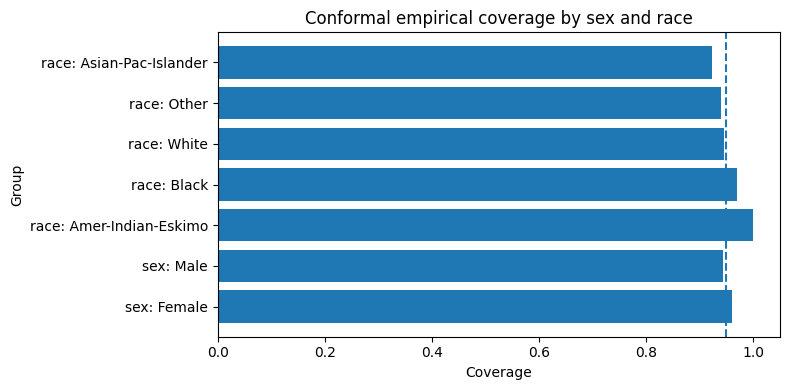

In [ ]:

# =========================
# 12. Conformal prediction: uncertainty and subgroup coverage
# =========================

def higher_quantile(values, q):
    """Compatibility wrapper for NumPy quantile with higher interpolation."""
    try:
        return np.quantile(values, q, method="higher")
    except TypeError:
        return np.quantile(values, q, interpolation="higher")

def conformal_prediction_audit(
    raw: pd.DataFrame,
    *,
    alpha: float = 0.05,
    include_race: bool = False,
    age_filter: bool = True,
    imputation: str = "author_mode",
    random_state: int = RANDOM_STATE,
):
    """
    Split data into train/calibration/test, fit the baseline-style logistic model,
    construct split-conformal prediction sets, and evaluate coverage.
    """
    X, y, meta, age_bounds = build_design_matrix(
        raw,
        include_race=include_race,
        age_filter=age_filter,
        imputation=imputation,
    )

    X_train_cal, X_test, y_train_cal, y_test, meta_train_cal, meta_test = train_test_split(
        X, y, meta, test_size=0.2, random_state=random_state
    )

    X_train, X_cal, y_train, y_cal, meta_train, meta_cal = train_test_split(
        X_train_cal, y_train_cal, meta_train_cal, test_size=0.25, random_state=random_state
    )
    # Effective split: 60% train, 20% calibration, 20% test.

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_cal_scaled = scaler.transform(X_cal)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(C=100, random_state=0, max_iter=1000, solver=AUDIT_LR_SOLVER)
    model.fit(X_train_scaled, y_train)

    cal_probs = model.predict_proba(X_cal_scaled)
    cal_scores = 1 - cal_probs[np.arange(len(y_cal)), y_cal]

    n_cal = len(cal_scores)
    q_level = min(1.0, np.ceil((n_cal + 1) * (1 - alpha)) / n_cal)
    qhat = higher_quantile(cal_scores, q_level)

    test_probs = model.predict_proba(X_test_scaled)
    prediction_sets = test_probs >= (1 - qhat)

    covered = prediction_sets[np.arange(len(y_test)), y_test]
    set_size = prediction_sets.sum(axis=1)

    overall = {
        "alpha": alpha,
        "target_coverage": 1 - alpha,
        "calibration_size": n_cal,
        "test_size": len(y_test),
        "qhat": qhat,
        "empirical_coverage": covered.mean(),
        "average_prediction_set_size": set_size.mean(),
        "singleton_rate": (set_size == 1).mean(),
        "ambiguous_two_label_set_rate": (set_size == 2).mean(),
        "empty_set_rate": (set_size == 0).mean(),
    }

    result_meta = add_derived_groups(meta_test).reset_index(drop=True)
    result_meta["covered"] = covered
    result_meta["set_size"] = set_size
    result_meta["ambiguous"] = (set_size == 2)

    return overall, result_meta, prediction_sets, test_probs, y_test

cp_overall, cp_meta_test, cp_sets, cp_probs, cp_y_test = conformal_prediction_audit(
    audit_raw_df,
    alpha=0.05,
    include_race=False,
    age_filter=True,
    imputation="author_mode",
)

display(Markdown("## Conformal prediction overall result"))
display(pd.DataFrame([cp_overall]))

cp_group_rows = []
for attr in ["sex", "race", "age_group", "education_group"]:
    for group, g in cp_meta_test.groupby(attr, dropna=False, observed=True):
        if len(g) < 30:
            continue
        cp_group_rows.append({
            "attribute": attr,
            "group": str(group),
            "n": len(g),
            "coverage": g["covered"].mean(),
            "average_set_size": g["set_size"].mean(),
            "ambiguous_two_label_set_rate": g["ambiguous"].mean(),
        })

audit_conformal_group_coverage = pd.DataFrame(cp_group_rows).sort_values(
    ["attribute", "coverage"], ascending=[True, True]
)

display(Markdown("## Conformal prediction coverage by subgroup"))
display(audit_conformal_group_coverage)

pd.DataFrame([cp_overall]).to_csv(AUDIT_OUTPUT_DIR / "19_conformal_overall.csv", index=False)
audit_conformal_group_coverage.to_csv(AUDIT_OUTPUT_DIR / "20_conformal_group_coverage.csv", index=False)

plt.figure(figsize=(8, 5))
plot_df = audit_conformal_group_coverage[audit_conformal_group_coverage["attribute"].isin(["sex", "race"])].copy()
if not plot_df.empty:
    plot_df = plot_df.copy()
    plot_df["label"] = plot_df["attribute"].astype(str) + ": " + plot_df["group"].astype(str)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df["coverage"])
    ax.axvline(0.95, linestyle="--")
    ax.set_title("Conformal empirical coverage by sex and race")
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Group")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No conformal subgroup coverage rows met the minimum group size threshold.")


In [ ]:

# =========================
# 13. Data protection / privacy-oriented audit
# =========================

# The original ADS does not implement differential privacy. As a concrete data-protection audit,
# we examine quasi-identifier uniqueness. High uniqueness implies that records may be easier to single out.
quasi_identifiers = [
    "age",
    "education",
    "marital.status",
    "occupation",
    "race",
    "sex",
    "native.country",
]

qi_counts = audit_raw_df.groupby(quasi_identifiers, dropna=False).size().rename("equivalence_class_size").reset_index()
audit_privacy_risk = audit_raw_df.merge(qi_counts, on=quasi_identifiers, how="left")

privacy_summary = pd.DataFrame([{
    "n_records": len(audit_privacy_risk),
    "min_equivalence_class_size": audit_privacy_risk["equivalence_class_size"].min(),
    "median_equivalence_class_size": audit_privacy_risk["equivalence_class_size"].median(),
    "percent_unique_k_eq_1": 100 * (audit_privacy_risk["equivalence_class_size"] == 1).mean(),
    "percent_k_lt_5": 100 * (audit_privacy_risk["equivalence_class_size"] < 5).mean(),
    "percent_k_lt_10": 100 * (audit_privacy_risk["equivalence_class_size"] < 10).mean(),
}])

display(Markdown("## Quasi-identifier uniqueness audit"))
display(privacy_summary)

display(Markdown("### Examples of small equivalence classes"))
display(
    audit_privacy_risk.sort_values("equivalence_class_size").head(20)[
        quasi_identifiers + ["income", "equivalence_class_size"]
    ]
)

privacy_recommendations = pd.DataFrame([
    {
        "topic": "Differential privacy",
        "audit_observation": "The original implementation trains on individual-level socio-demographic records without a privacy mechanism.",
        "potential_improvement": "If releasing model statistics or trained models from sensitive data, consider DP-SGD / DP logistic regression, privacy accounting, and reporting epsilon/delta."
    },
    {
        "topic": "Data minimization",
        "audit_observation": "Features such as native.country, race, sex, occupation, and marital status may be sensitive or act as proxies.",
        "potential_improvement": "Justify each feature's necessity, remove unnecessary fields, and document the expected benefit vs privacy/fairness risk."
    },
    {
        "topic": "Quasi-identifier risk",
        "audit_observation": "Small equivalence classes indicate potential singling-out risk if row-level data is shared.",
        "potential_improvement": "Avoid public release of row-level identifiable combinations; aggregate or generalize high-risk quasi-identifiers."
    },
])

display(Markdown("## Privacy and differential-privacy discussion points for the report"))
display(privacy_recommendations)

privacy_summary.to_csv(AUDIT_OUTPUT_DIR / "21_privacy_quasi_identifier_summary.csv", index=False)
privacy_recommendations.to_csv(AUDIT_OUTPUT_DIR / "22_privacy_recommendations.csv", index=False)


## Quasi-identifier uniqueness audit

,n_records,min_equivalence_class_size,median_equivalence_class_size,percent_unique_k_eq_1,percent_k_lt_5,percent_k_lt_10
0,32561,1,3.0,36.767913,61.905347,77.245785


### Examples of small equivalence classes

,age,education,marital.status,occupation,race,sex,native.country,income,equivalence_class_size
28639,34,Some-college,Never-married,Handlers-cleaners,Black,Male,?,<=50K,1
1,82,HS-grad,Widowed,Exec-managerial,White,Female,United-States,<=50K,1
2,66,Some-college,Widowed,?,Black,Female,United-States,<=50K,1
3,54,7th-8th,Divorced,Machine-op-inspct,White,Female,United-States,<=50K,1
4,41,Some-college,Separated,Prof-specialty,White,Female,United-States,<=50K,1
6,38,10th,Separated,Adm-clerical,White,Male,United-States,<=50K,1
7,74,Doctorate,Never-married,Prof-specialty,White,Female,United-States,>50K,1
8,68,HS-grad,Divorced,Prof-specialty,White,Female,United-States,<=50K,1
9,41,Some-college,Never-married,Craft-repair,White,Male,?,>50K,1
10,45,Doctorate,Divorced,Prof-specialty,Black,Female,United-States,>50K,1


## Privacy and differential-privacy discussion points for the report

,topic,audit_observation,potential_improvement
0,Differential privacy,The original implementation trains on individu...,If releasing model statistics or trained model...
1,Data minimization,"Features such as native.country, race, sex, oc...","Justify each feature's necessity, remove unnec..."
2,Quasi-identifier risk,Small equivalence classes indicate potential s...,Avoid public release of row-level identifiable...
